# Evaluate Node Heights

In [1]:
from Bio import Nexus, Phylo, SeqIO
from collections import defaultdict
from io import StringIO

import matplotlib.pyplot as plt
from matplotlib import gridspec

import seaborn as sns

import pandas as pd
import numpy as np

import re
from pathlib import Path

from itertools import combinations

from evaluation_helpers import *

In [14]:
input_csv = "../scripts/successful_mcmc_runs.csv" 
overview_df, df_failed = process_results(input_csv)
overview_df.head()

#overview_df_ = add_tree_information(overview_df_)
overview_df_ = pd.read_pickle("../results/run1/evaluation/df_pop_info.pkl")
overview_df_.head()

tree_metrics_combined = pd.read_csv("../results/run1/evaluation/tree_metrics_combined.csv")
tree_metrics_combined['cum_pop_size_error_abs_relsim'] = np.abs(tree_metrics_combined['cum_pop_size_error_relsim'])

tree_metrics_combined_internal = tree_metrics_combined[tree_metrics_combined['internal'] == True]

/var/folders/l3/cr7pvqjn2054djbp5cf7qbd40000gn/T/ipykernel_34071/4224247685.py:9: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  tree_metrics_combined = pd.read_csv("../results/run1/evaluation/tree_metrics_combined.csv")


## Are estimated confidence intervals matching true simulated node heights

In [4]:
# height only makes sense for internal nodes

tree_metrics_combined_linearconstant = tree_metrics_combined[tree_metrics_combined["sampling"] == "linearconstant"].copy()
tree_metrics_combined_independenthomochronous = tree_metrics_combined[tree_metrics_combined["sampling"] == "independenthomochronous"].copy()

display(tree_metrics_combined[(tree_metrics_combined["model"] == "skyline") & (tree_metrics_combined["internal"] == True)].height_inside_ci.value_counts())
display(tree_metrics_combined[(tree_metrics_combined["model"] == "constcoal") & (tree_metrics_combined["internal"] == True)].height_inside_ci.value_counts())

display(tree_metrics_combined_linearconstant[(tree_metrics_combined_linearconstant["model"] == "skyline") & (tree_metrics_combined_linearconstant["internal"] == True)].height_inside_ci.value_counts())
display(tree_metrics_combined_linearconstant[(tree_metrics_combined_linearconstant["model"] == "constcoal") & (tree_metrics_combined_linearconstant["internal"] == True)].height_inside_ci.value_counts())

display(tree_metrics_combined_independenthomochronous[(tree_metrics_combined_independenthomochronous["model"] == "skyline") & (tree_metrics_combined_independenthomochronous["internal"] == True)].height_inside_ci.value_counts())
display(tree_metrics_combined_independenthomochronous[(tree_metrics_combined_independenthomochronous["model"] == "constcoal") & (tree_metrics_combined_independenthomochronous["internal"] == True)].height_inside_ci.value_counts())

height_inside_ci
True     384060
False     88901
Name: count, dtype: int64

height_inside_ci
True     398100
False     74861
Name: count, dtype: int64

height_inside_ci
True     207952
False     77014
Name: count, dtype: int64

height_inside_ci
True     222307
False     62659
Name: count, dtype: int64

height_inside_ci
True     176108
False     11887
Name: count, dtype: int64

height_inside_ci
True     175793
False     12202
Name: count, dtype: int64

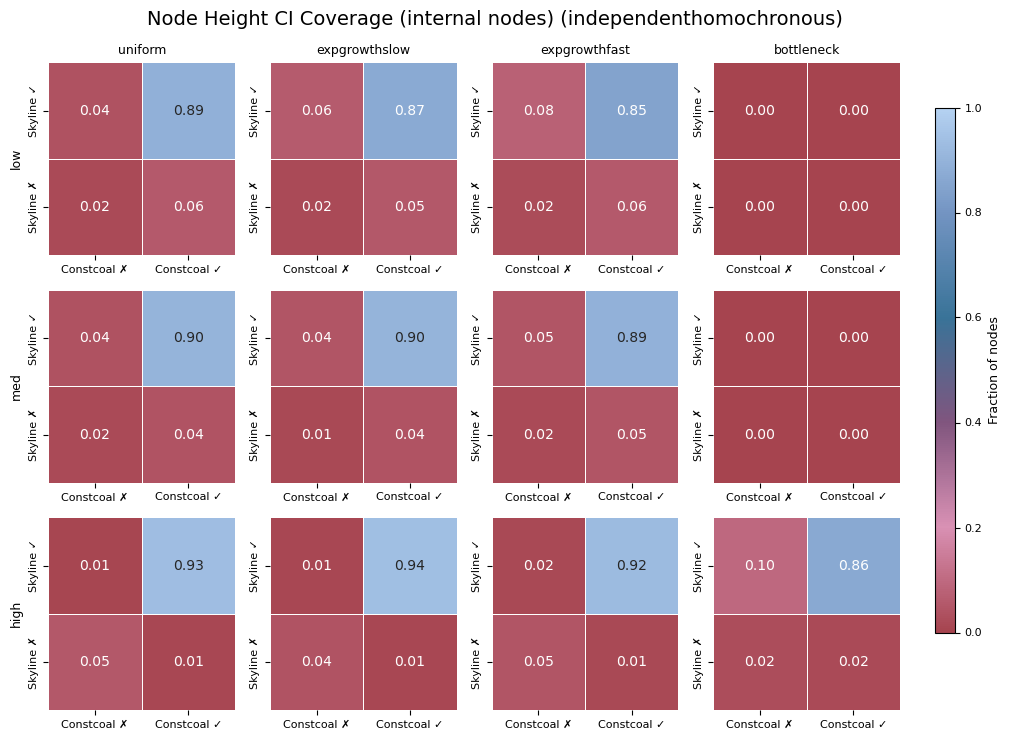

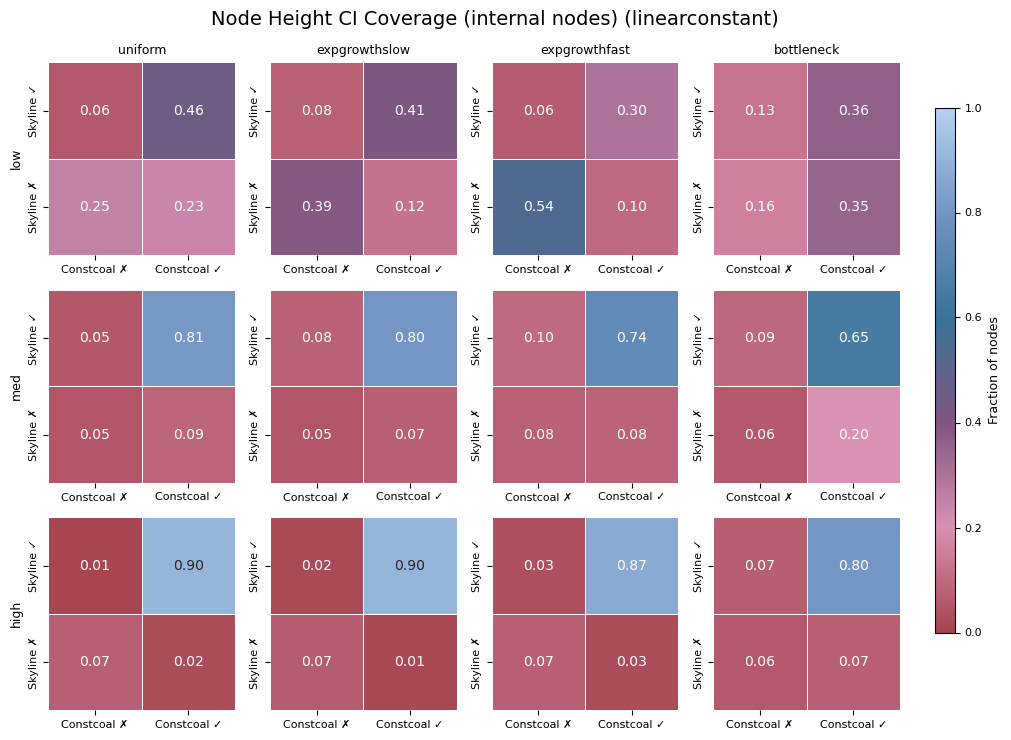

In [3]:
plot_ci_coverage_heatmap_nodes(tree_metrics_combined_internal, mode="height")

## General boxplot node height errors

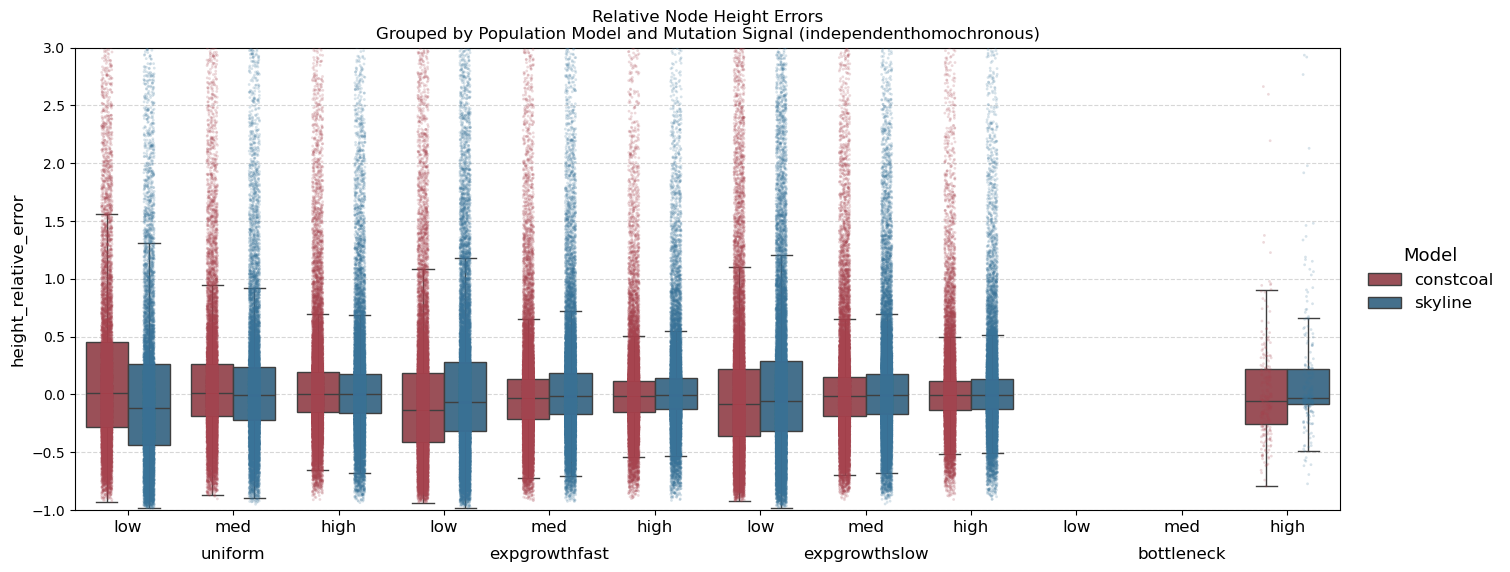

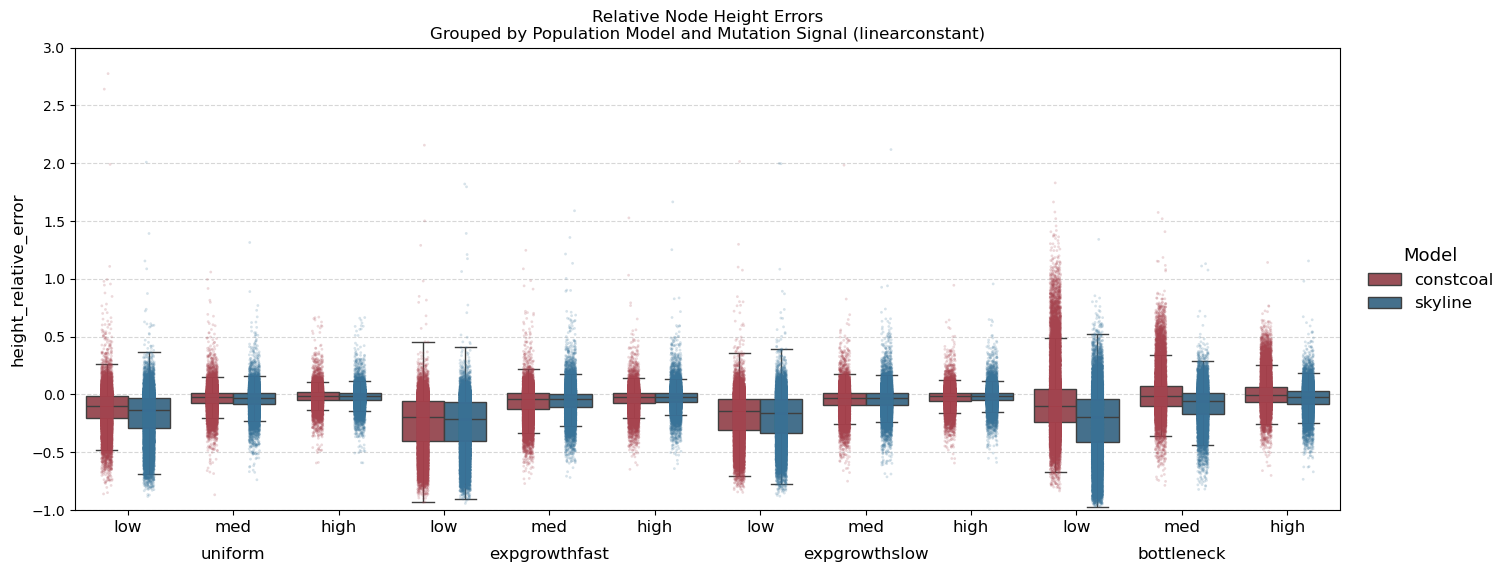

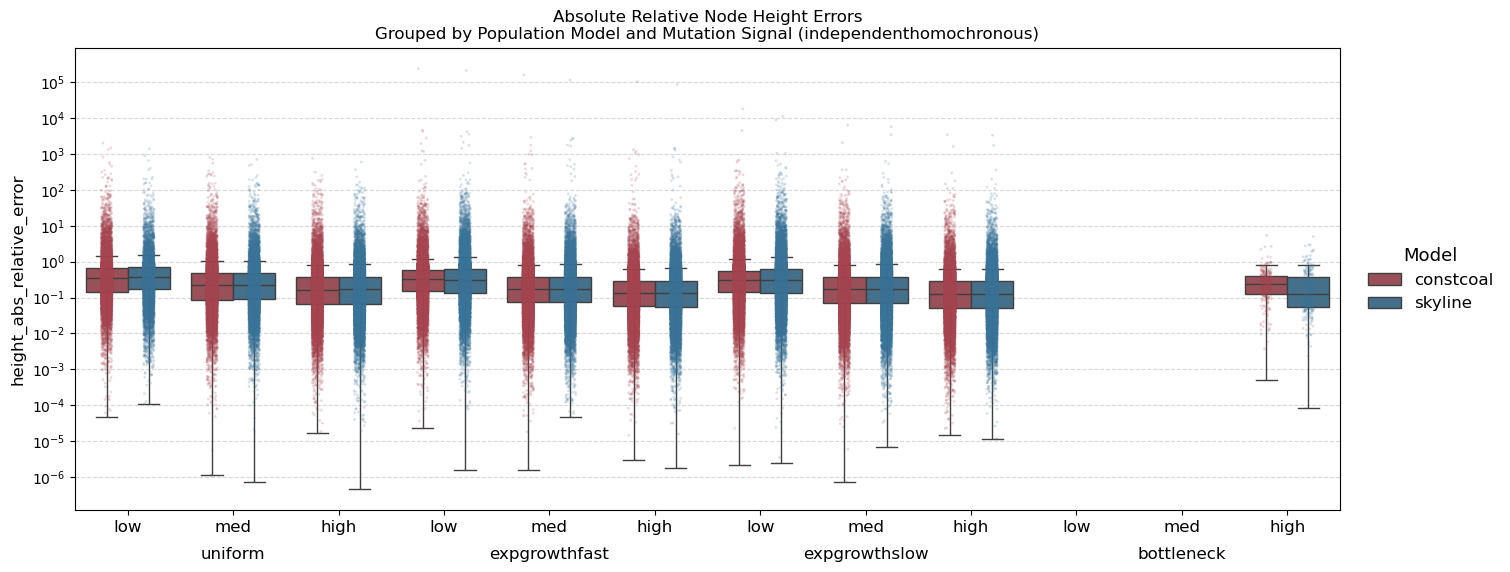

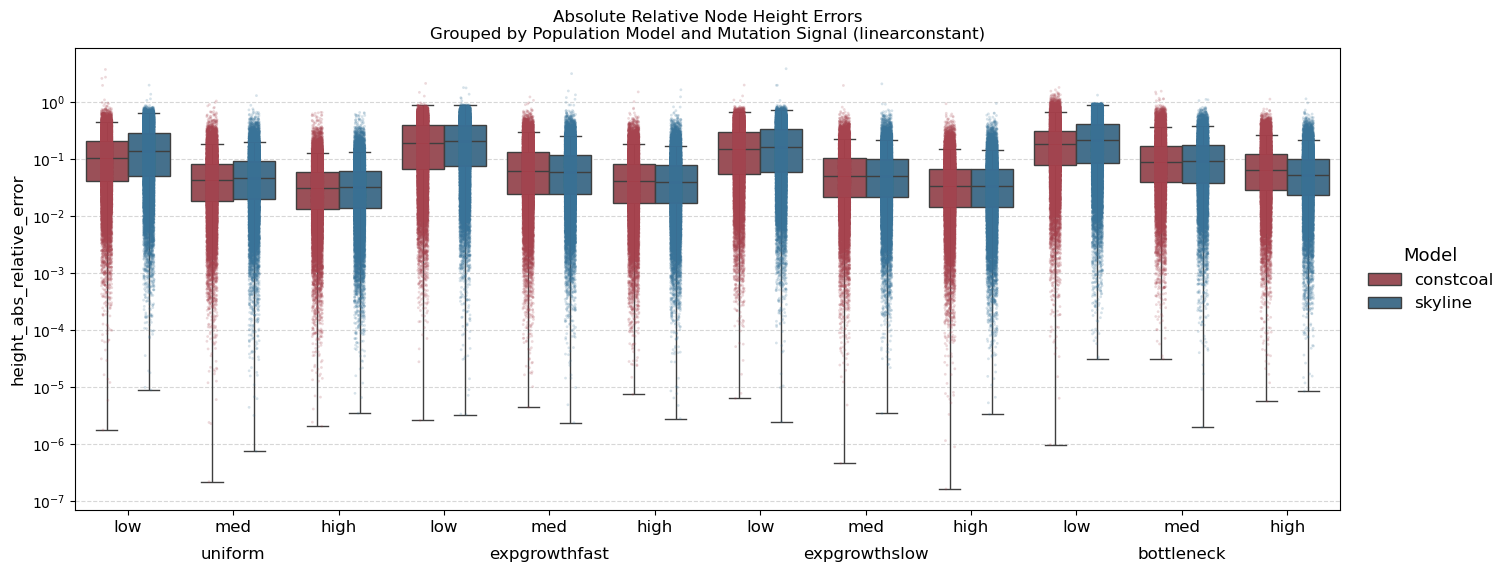

In [6]:
# relative error
boxplot_branch_length_errors(tree_metrics_combined[tree_metrics_combined["internal"] == True], metric="height_relative_error", sampling = "independenthomochronous", title="Relative Node Height Errors\nGrouped by Population Model and Mutation Signal", logscale = False, y_range= (-1,3))
boxplot_branch_length_errors(tree_metrics_combined[tree_metrics_combined["internal"] == True], metric="height_relative_error", sampling = "linearconstant", title="Relative Node Height Errors\nGrouped by Population Model and Mutation Signal", logscale = False, y_range= (-1,3))

# absolute relative error
boxplot_branch_length_errors(tree_metrics_combined[tree_metrics_combined["internal"] == True], metric="height_abs_relative_error", sampling = "independenthomochronous", title="Absolute Relative Node Height Errors\nGrouped by Population Model and Mutation Signal", logscale = True)
boxplot_branch_length_errors(tree_metrics_combined[tree_metrics_combined["internal"] == True], metric="height_abs_relative_error", sampling = "linearconstant", title="Absolute Relative Node Height Errors\nGrouped by Population Model and Mutation Signal", logscale = True)

## Error development over time
1. Detailed view of early time points
2. full time period

Observations:
- Fast exponential growth (and slow exponential growth):
    - skyline starts becoming the better estimate starting from time ranges of 100
    - interesting to see how the constcoal becomes better when the lines cross and then again worse after
    - in late time points skyline behaves a lot better for low mut. signal and less of an effect for higher mut. sig.
- Bottleneck:
    - for high and med mutsig we see that it is better represented by the skyline
    - for lowmutsig the phase in which the skyline grows before and after is worse than the constant but within the bottleneck the skyline is better


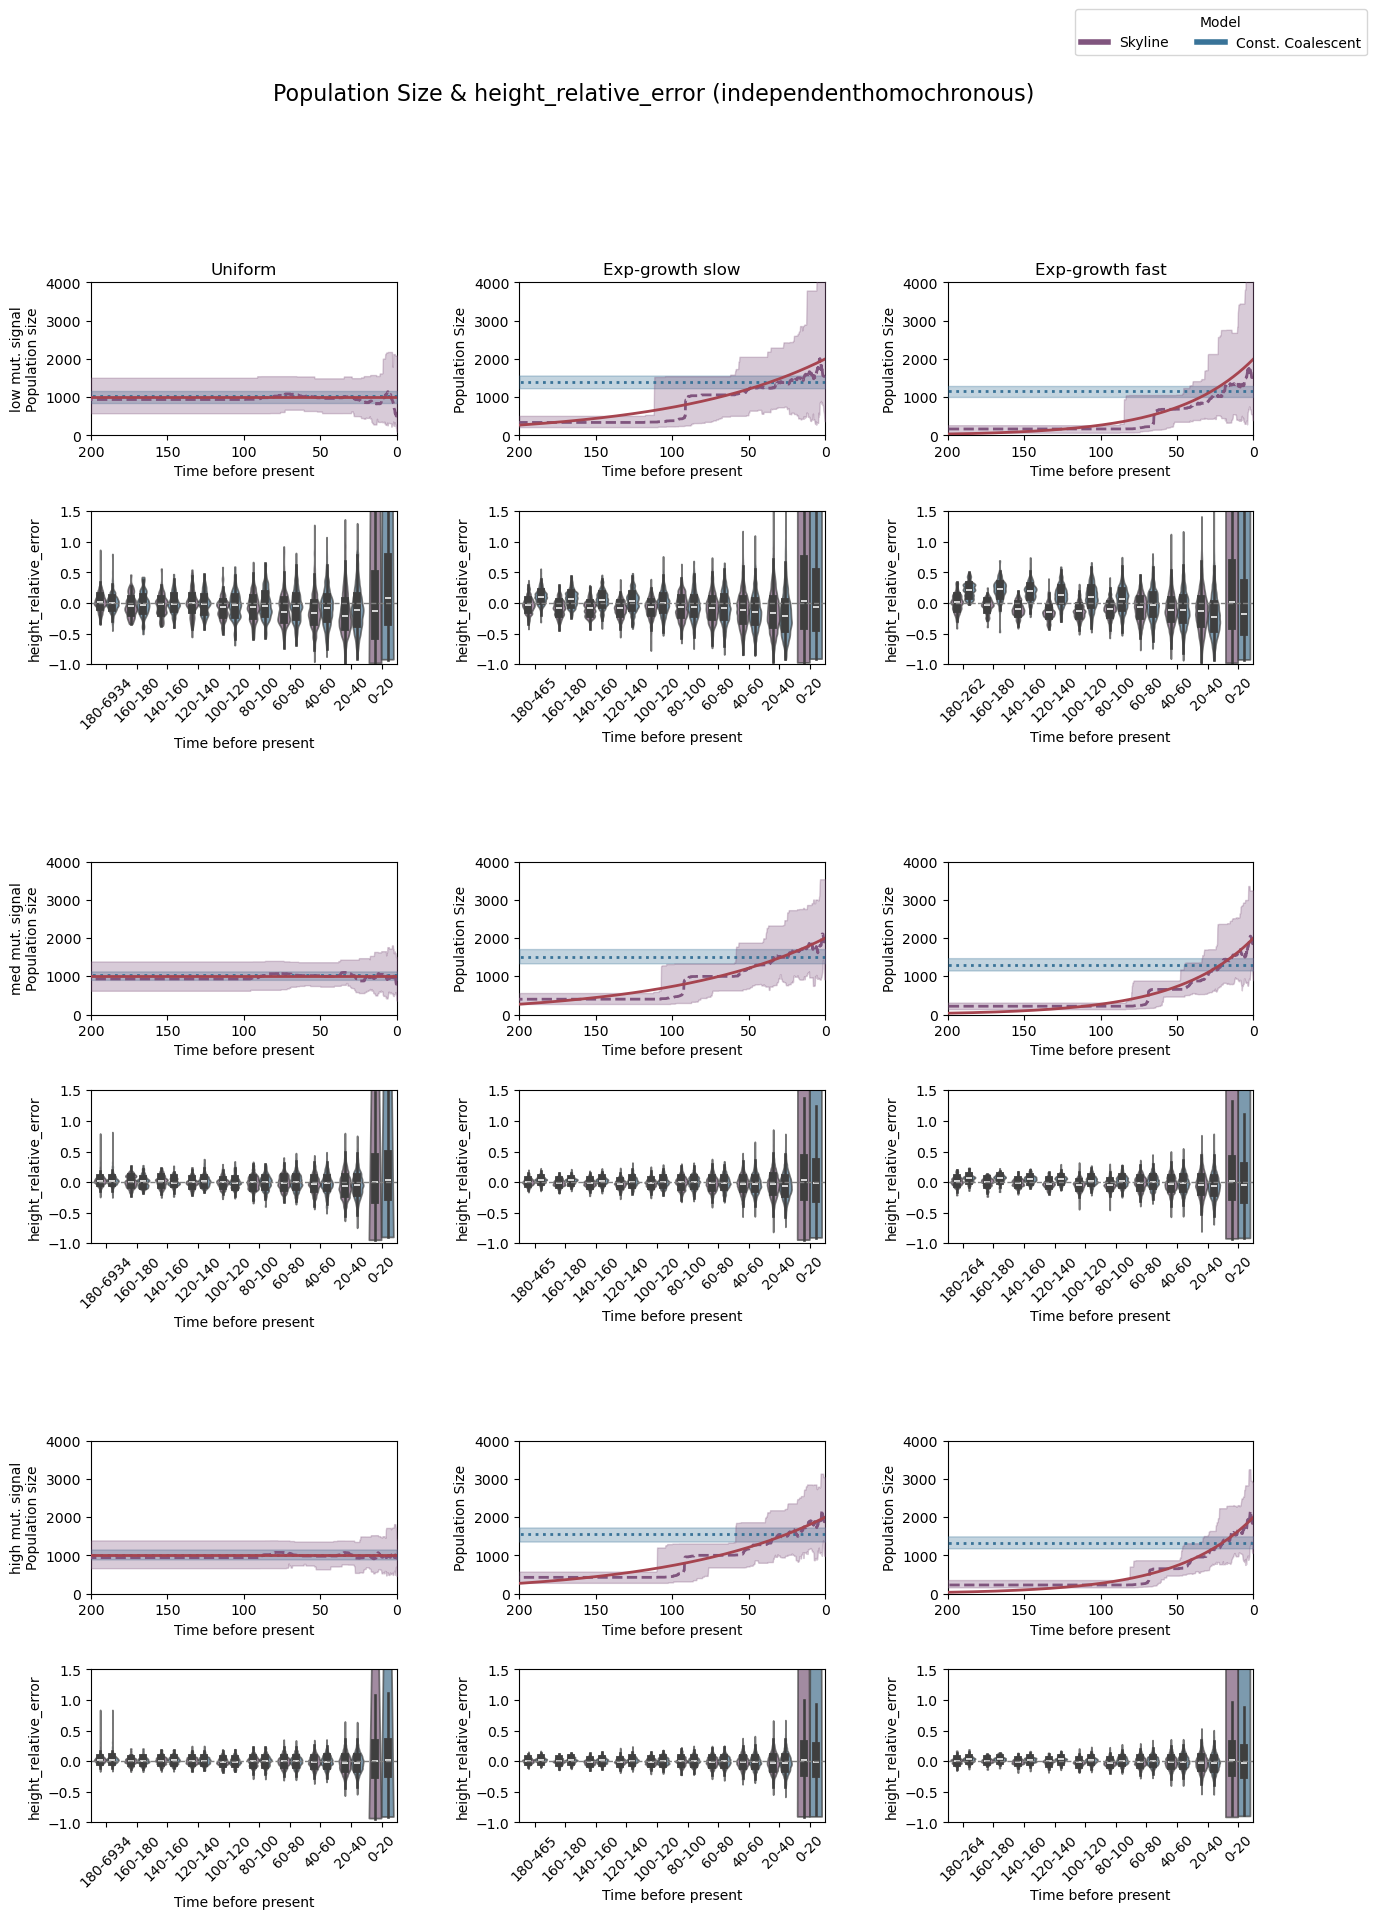

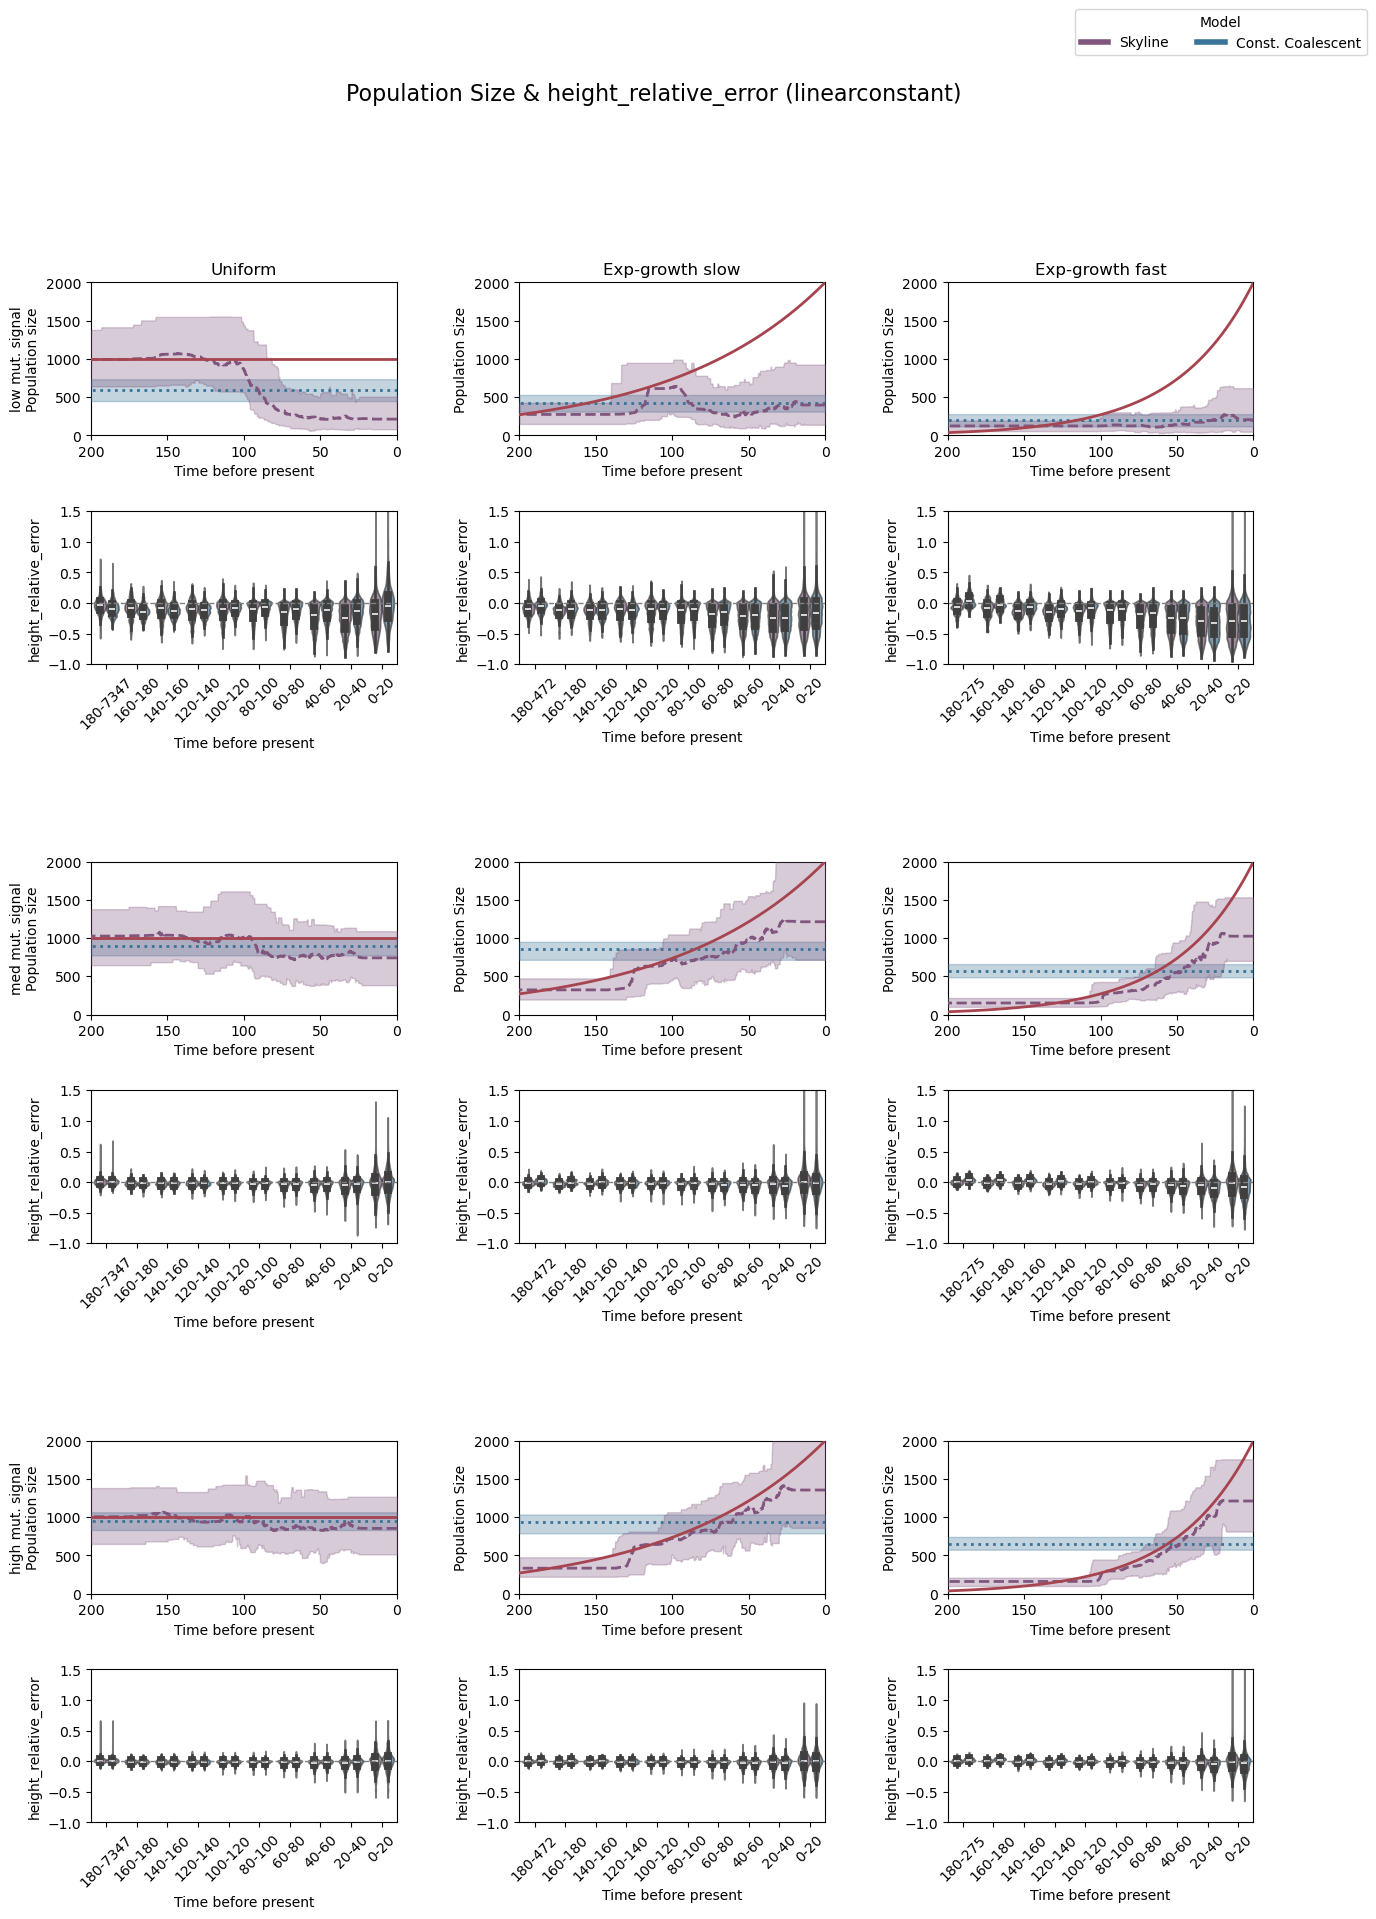

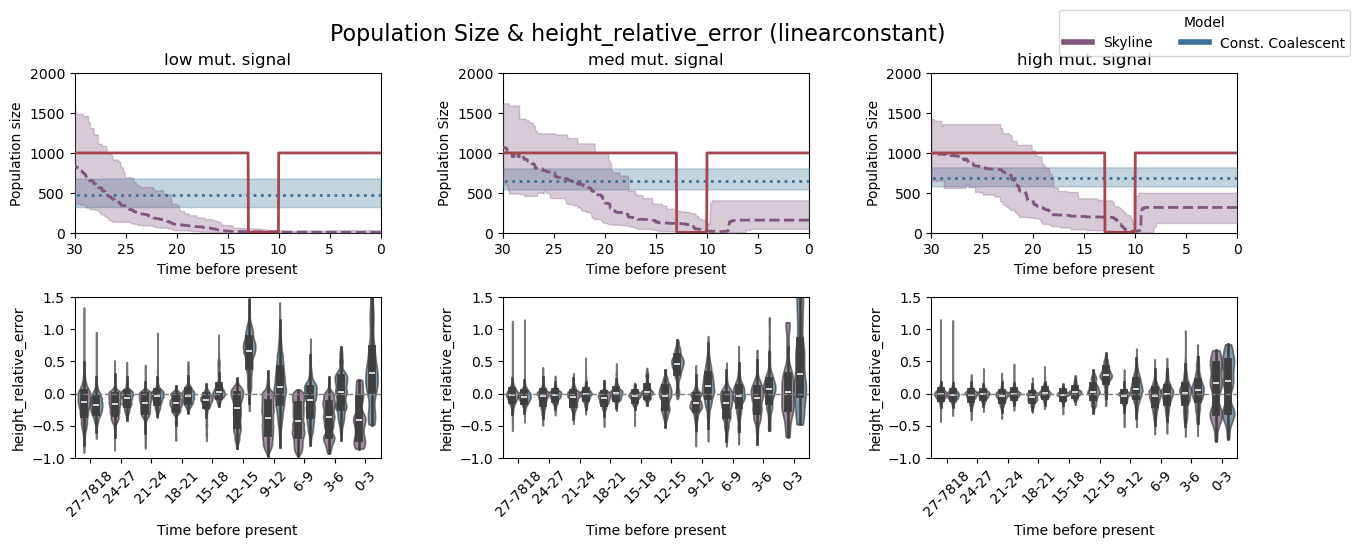

In [10]:
# branch lengths are plotted at the simulated (true) node height of the starting point of the branch, restricted to the last 100 years because that's where most of the population size changes happen and where we have most of the data points

plot_combined_population_and_error(
    df_population=overview_df_,
    df_error=tree_metrics_combined_internal,
    pop_models=["uniform", "expgrowthslow", "expgrowthfast"],
    time_horizon=200,
    sampling="independenthomochronous",
    pop_y_range=(0, 4000),
    error_y_range=(-1, 1.5),
    bin_width=20,
    error_col="height_relative_error",
    x_col="height_sim",
    plot_type="violin"
)

plot_combined_population_and_error(
    df_population=overview_df_,
    df_error=tree_metrics_combined_internal,
    pop_models=["uniform", "expgrowthslow", "expgrowthfast"],
    time_horizon=200,
    sampling="linearconstant",
    pop_y_range=(0, 2000),
    error_y_range=(-1, 1.5),
    bin_width=20,
    error_col="height_relative_error",
    x_col="height_sim",
    plot_type="violin"
)

plot_combined_population_and_error(
    df_population=overview_df_,
    df_error=tree_metrics_combined_internal,
    pop_models=["bottleneck"],
    time_horizon=30,
    sampling="linearconstant",
    pop_y_range=(0, 2000),
    error_y_range=(-1, 1.5),
    bin_width=3,
    error_col="height_relative_error",
    x_col="height_sim",
    plot_type="violin"
)

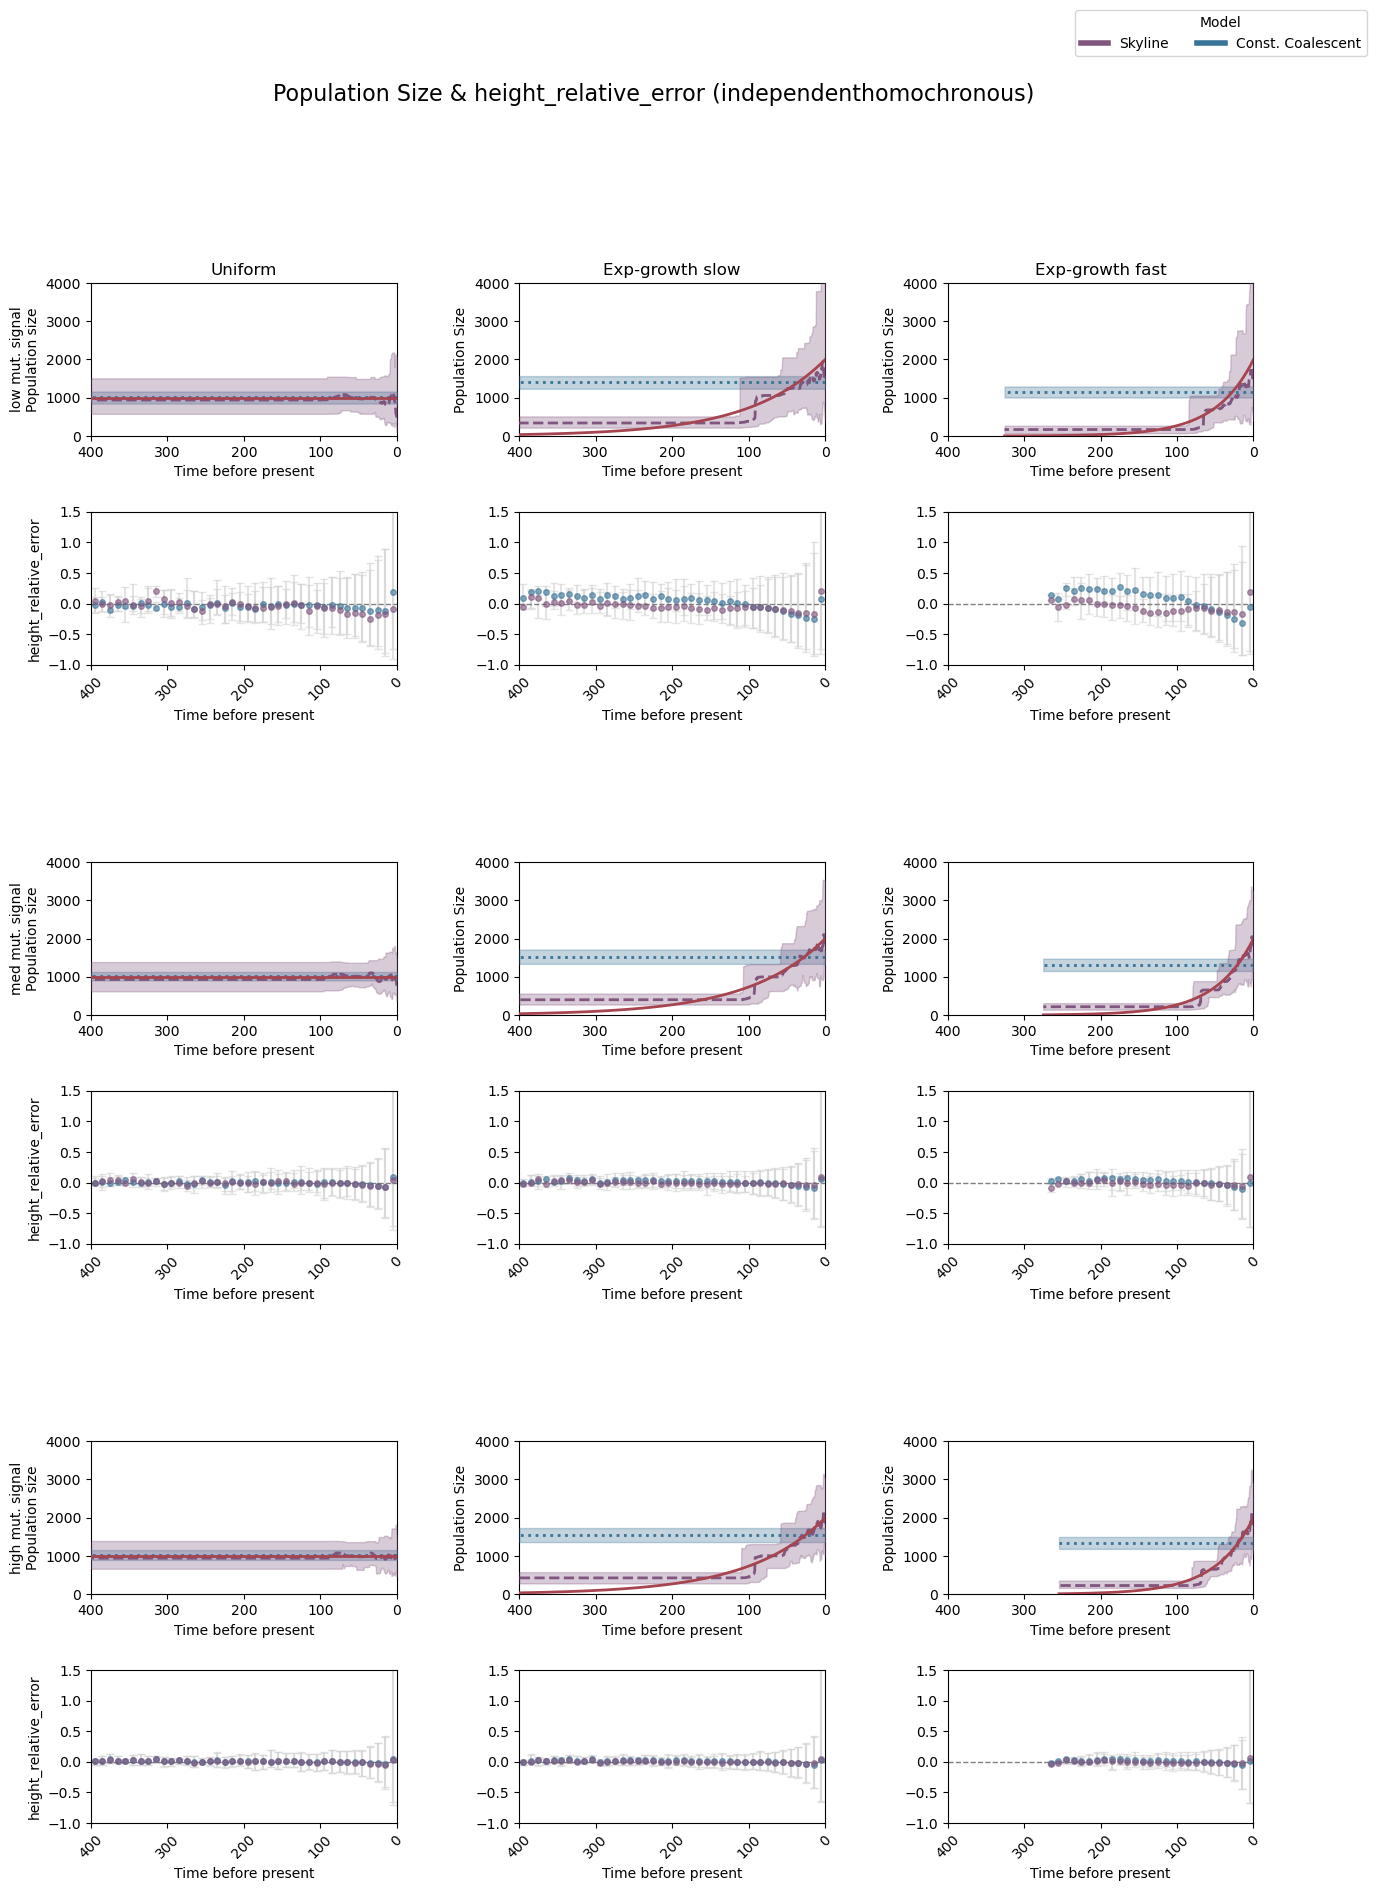

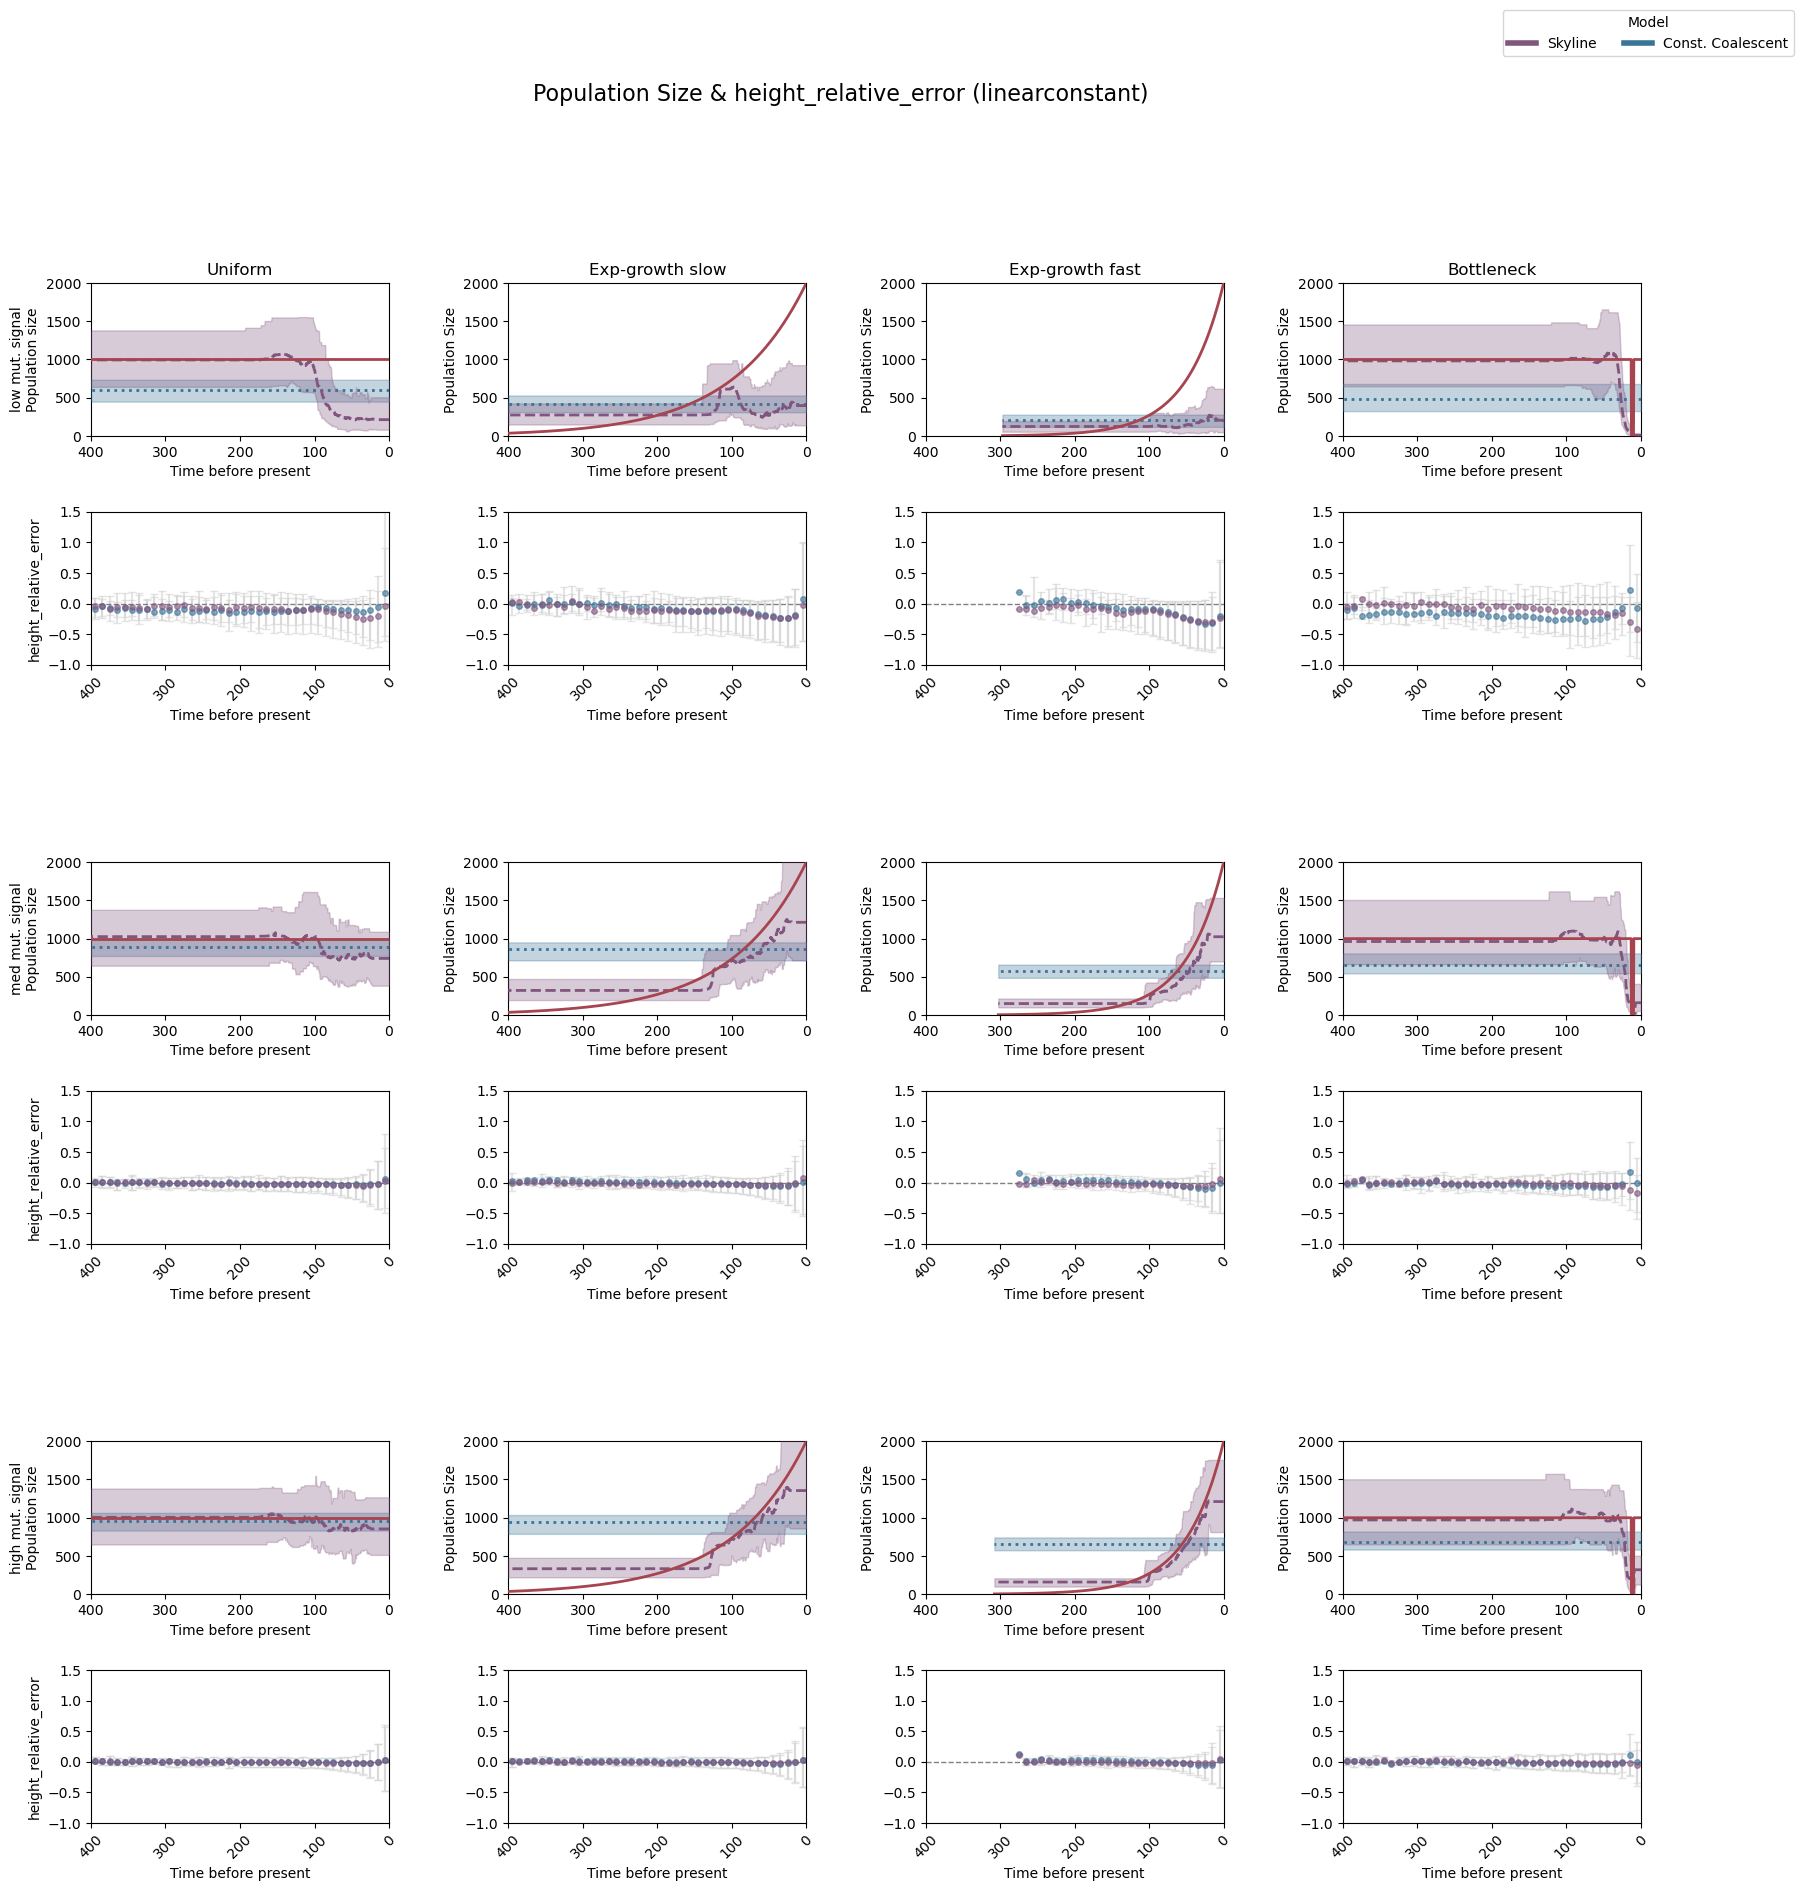

In [9]:
# scatter plot

plot_combined_population_and_error(
    df_population=overview_df_,
    df_error=tree_metrics_combined_internal,
    pop_models=["uniform", "expgrowthslow", "expgrowthfast"],
    time_horizon=400,
    sampling="independenthomochronous",
    pop_y_range=(0, 4000),
    error_y_range=(-1, 1.5),
    bin_width=10,
    error_col="height_relative_error",
    x_col="height_sim",
    plot_type="scatter"
)

plot_combined_population_and_error(
    df_population=overview_df_,
    df_error=tree_metrics_combined_internal,
    time_horizon=400,
    sampling="linearconstant",
    pop_y_range=(0, 2000),
    error_y_range=(-1, 1.5),
    bin_width=10,
    error_col="height_relative_error",
    x_col="height_sim",
    plot_type="scatter"
)

# Compare population error and Branch Length error
1. Past 200 years
    - rel diff. node height vs. rel diff. in pop. size, time bin width = 5 years with a minimum of 10 values, homochronous
    - absolute rel diff. node height vs. rel diff. in pop. size, time bin width = 5 years with a minimum of 10 values, homochronous
    - rel diff. node height vs. rel cumulative diff. in pop. size, time bin width = 5 years with a minimum of 10 values, homochronous
    - rel diff. node height vs. rel diff. in pop. size, time bin width = 5 years with a minimum of 10 values, heterochronous
    - rel diff. node height vs. rel diff. in pop. size, time bin width = 5 years with a minimum of 10 values, heterochronous, detailed view bottleneck
2. All time points
    - rel diff. node height vs. rel diff. in pop. size, time bin width = 5 years with a minimum of 10 values, homochronous
    - absolute rel diff. node height vs. rel diff. in pop. size, time bin width = 5 years with a minimum of 10 values, homochronous
    - rel diff. node height vs. rel cumulative diff. in pop. size, time bin width = 5 years with a minimum of 10 values, homochronous
    - rel diff. node height vs. rel diff. in pop. size, time bin width = 5 years with a minimum of 10 values, heterochronous
    - rel diff. node height vs. rel diff. in pop. size, time bin width = 5 years with a minimum of 10 values, heterochronous, detailed view bottleneck

3. Non-relative errors over all time points
    - diff in node height over diff in pop. size, time bin width: 5, minimum n. values: 10 homochronous
    - diff in node height over cumulative diff in pop. size, time bin width: 5, minimum n. values: 10 homochronous
    - diff in node height over diff in pop. size, time bin width: 5, minimum n. values: 10 heterochronous
    - diff in node height over cumulative diff in pop. size, time bin width: 5, minimum n. values: 10 heterochronous


Observations:
- error seems to be increasing linearly for constcoal with diff. in population size (not cumulative) but not go through 0 --> compare with cumulative difference
- node height errors go in different directions for skyline and constcoal but there is still a difference visible if looking at the absolute relative branch length error
- potential reason why overall node height error distribution shows very similar errors between skyline and constcoal could be that constcoal is wrong at early and late time point (less good estimation of population size) but quite good when the true and estimated pop. size lines cross (middle) while skyline population estimates are always a little bit wrong even though they overall follow the true population size better
- looking at cumulative pop. size error we would expect to get the least node height error at a population size of 0, however this is a little bit shifted even for cumulative pop size errors (less than just for general pop size error)

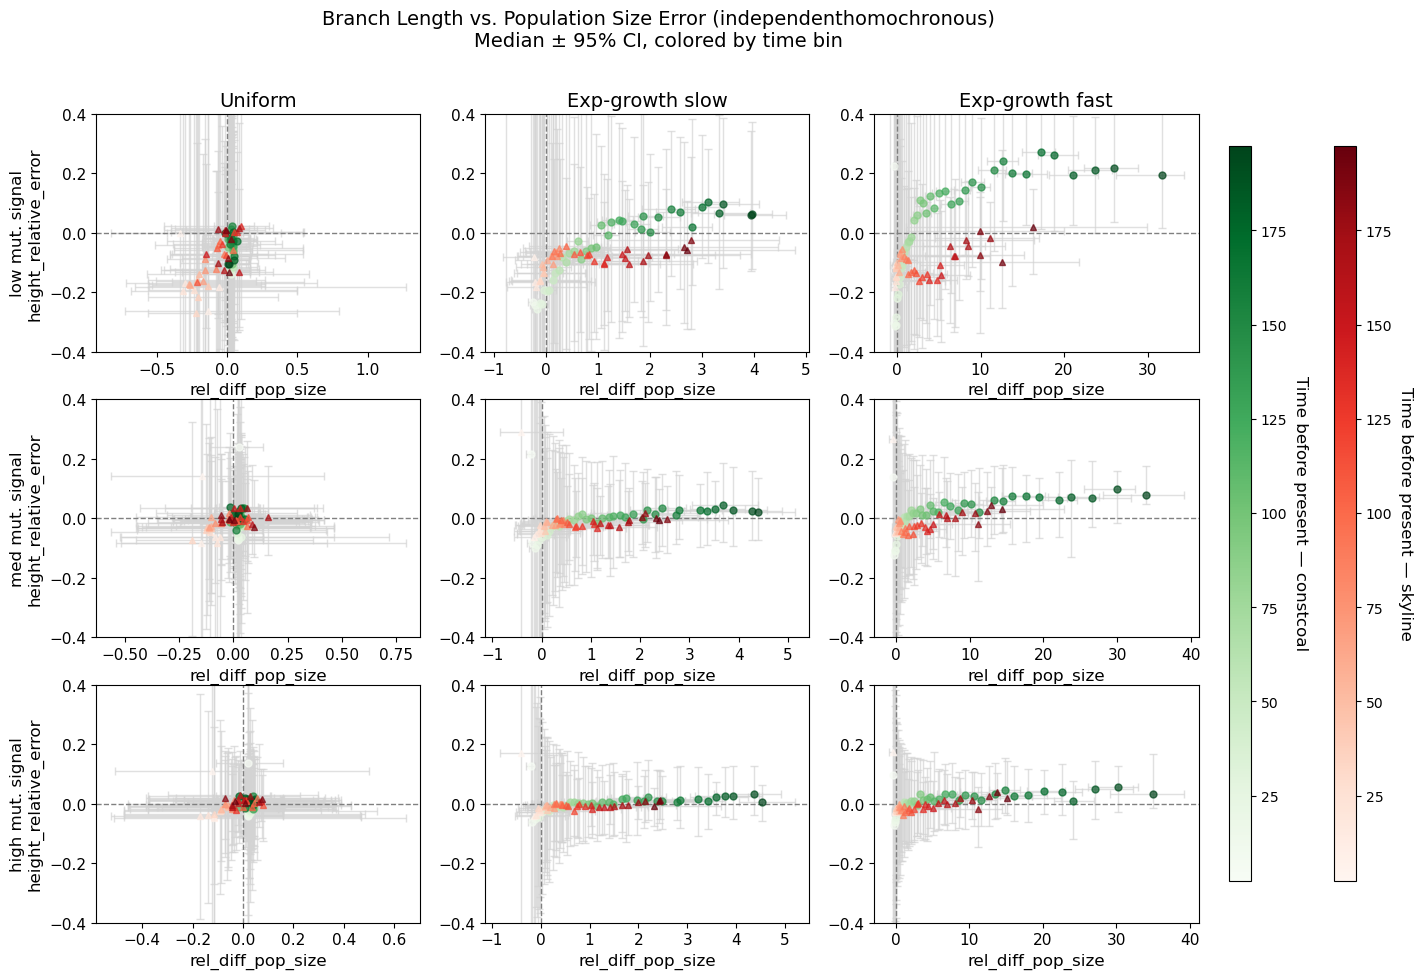

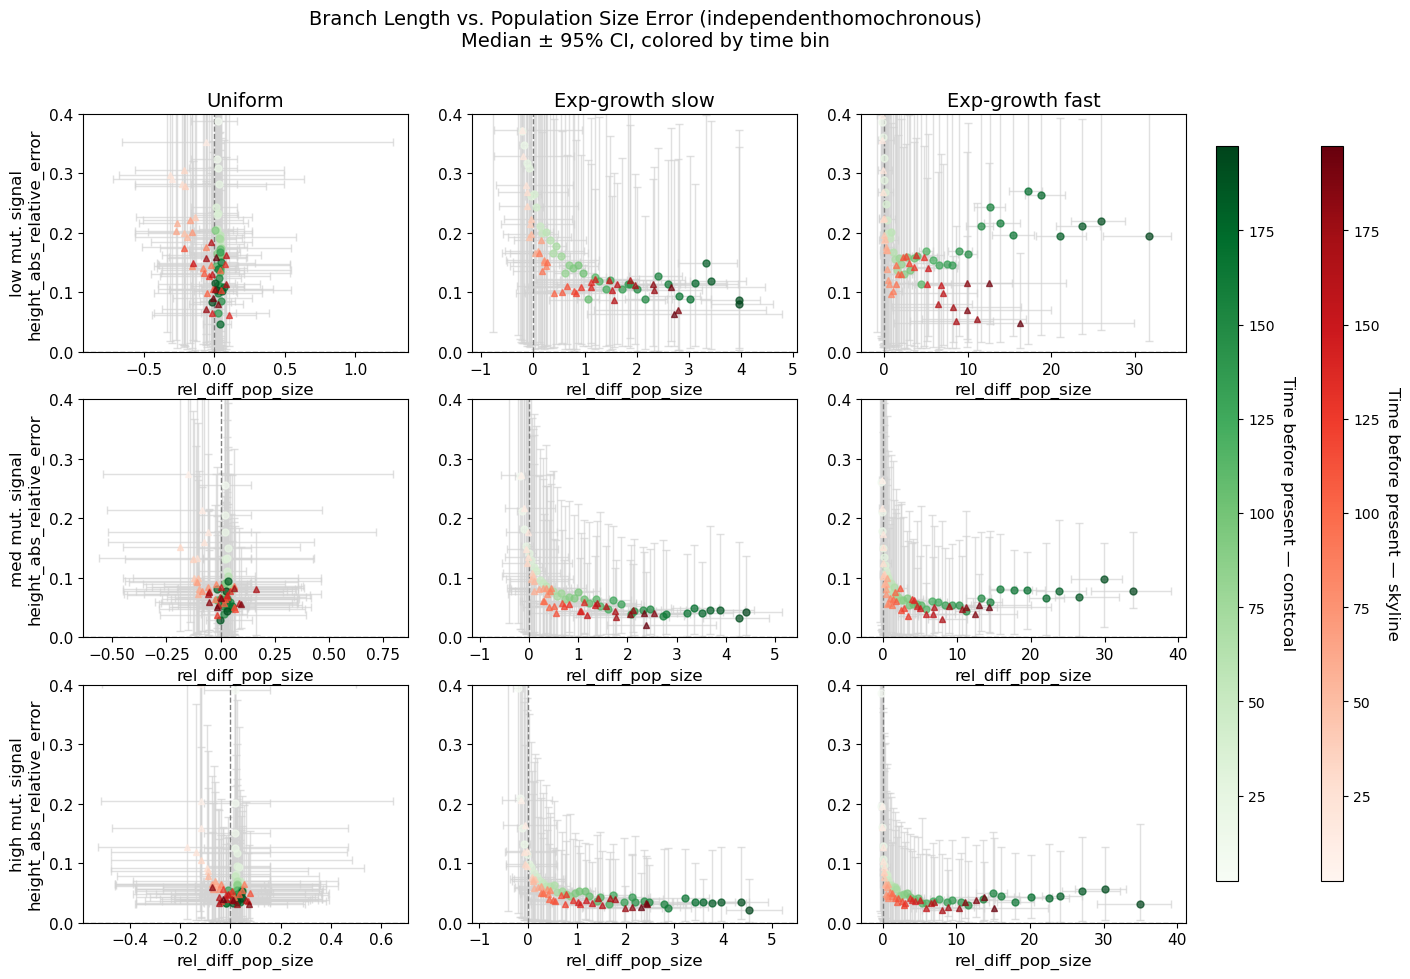

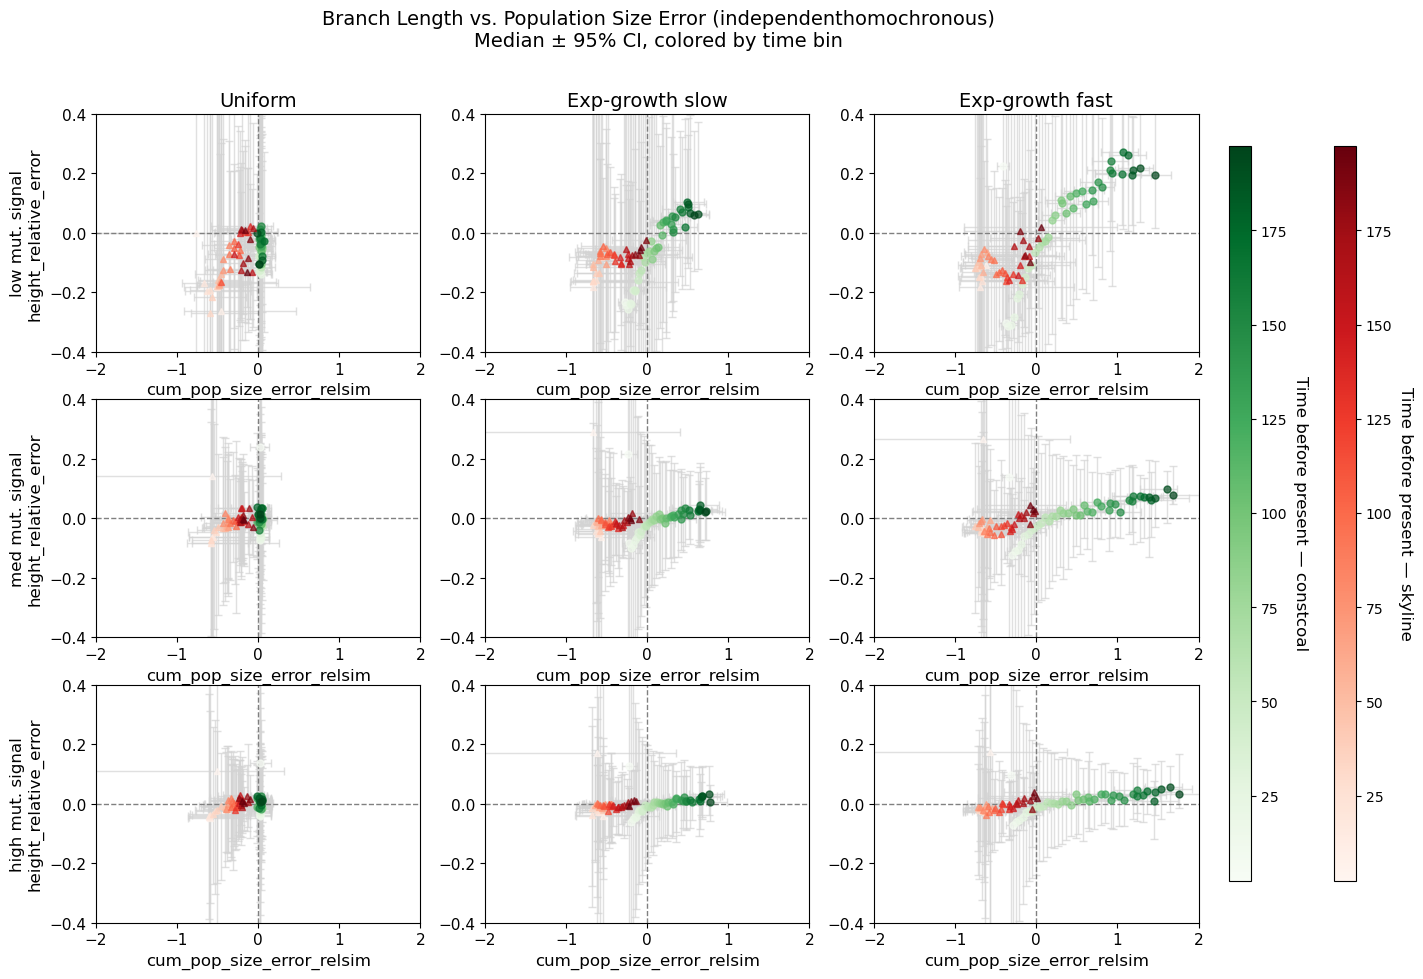

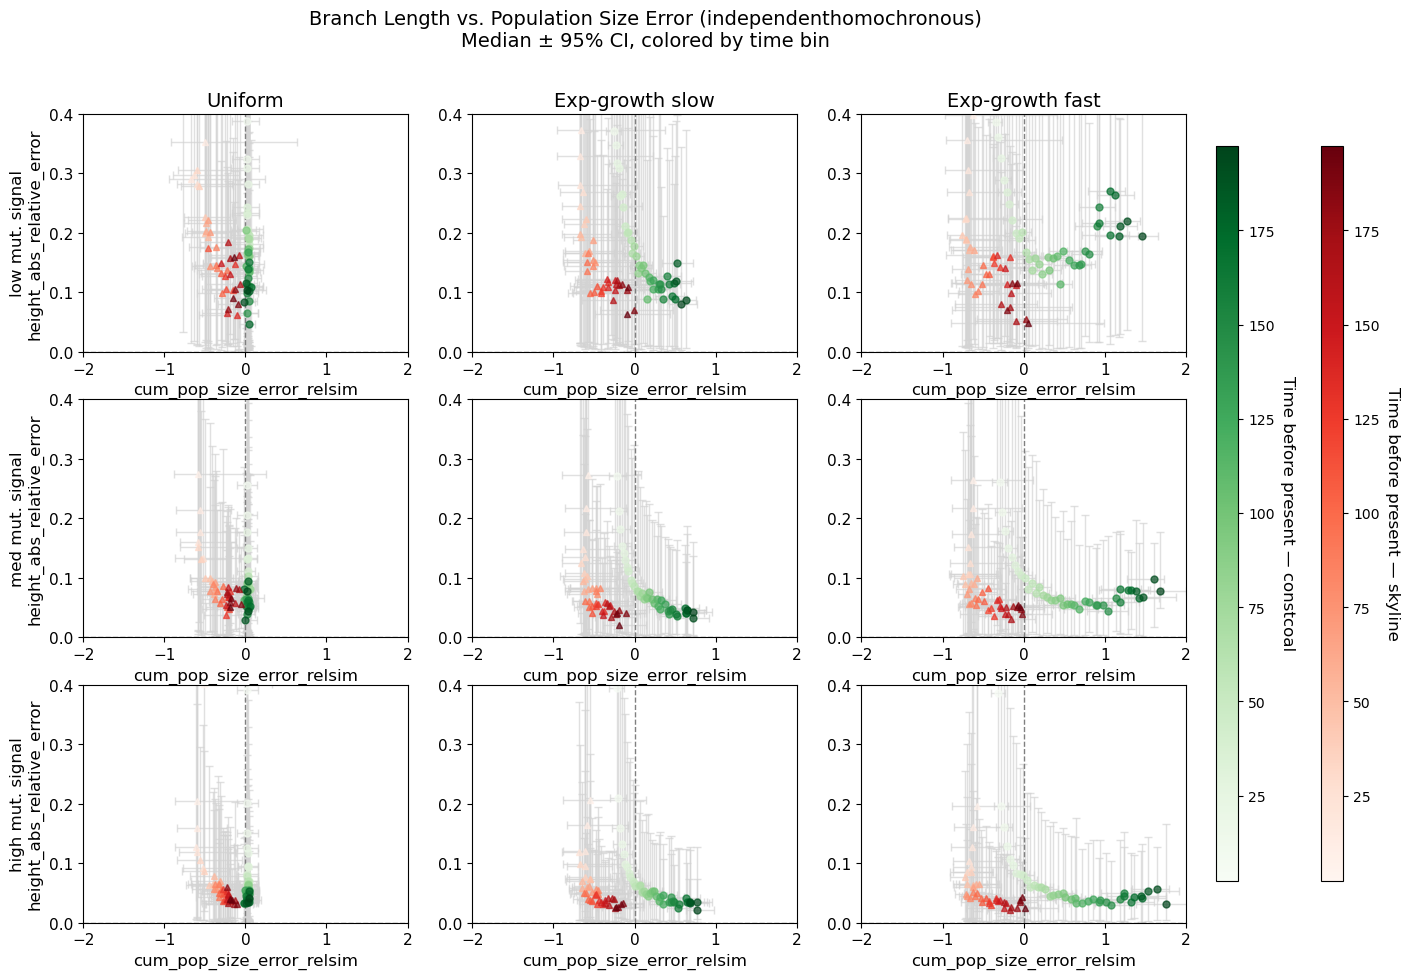

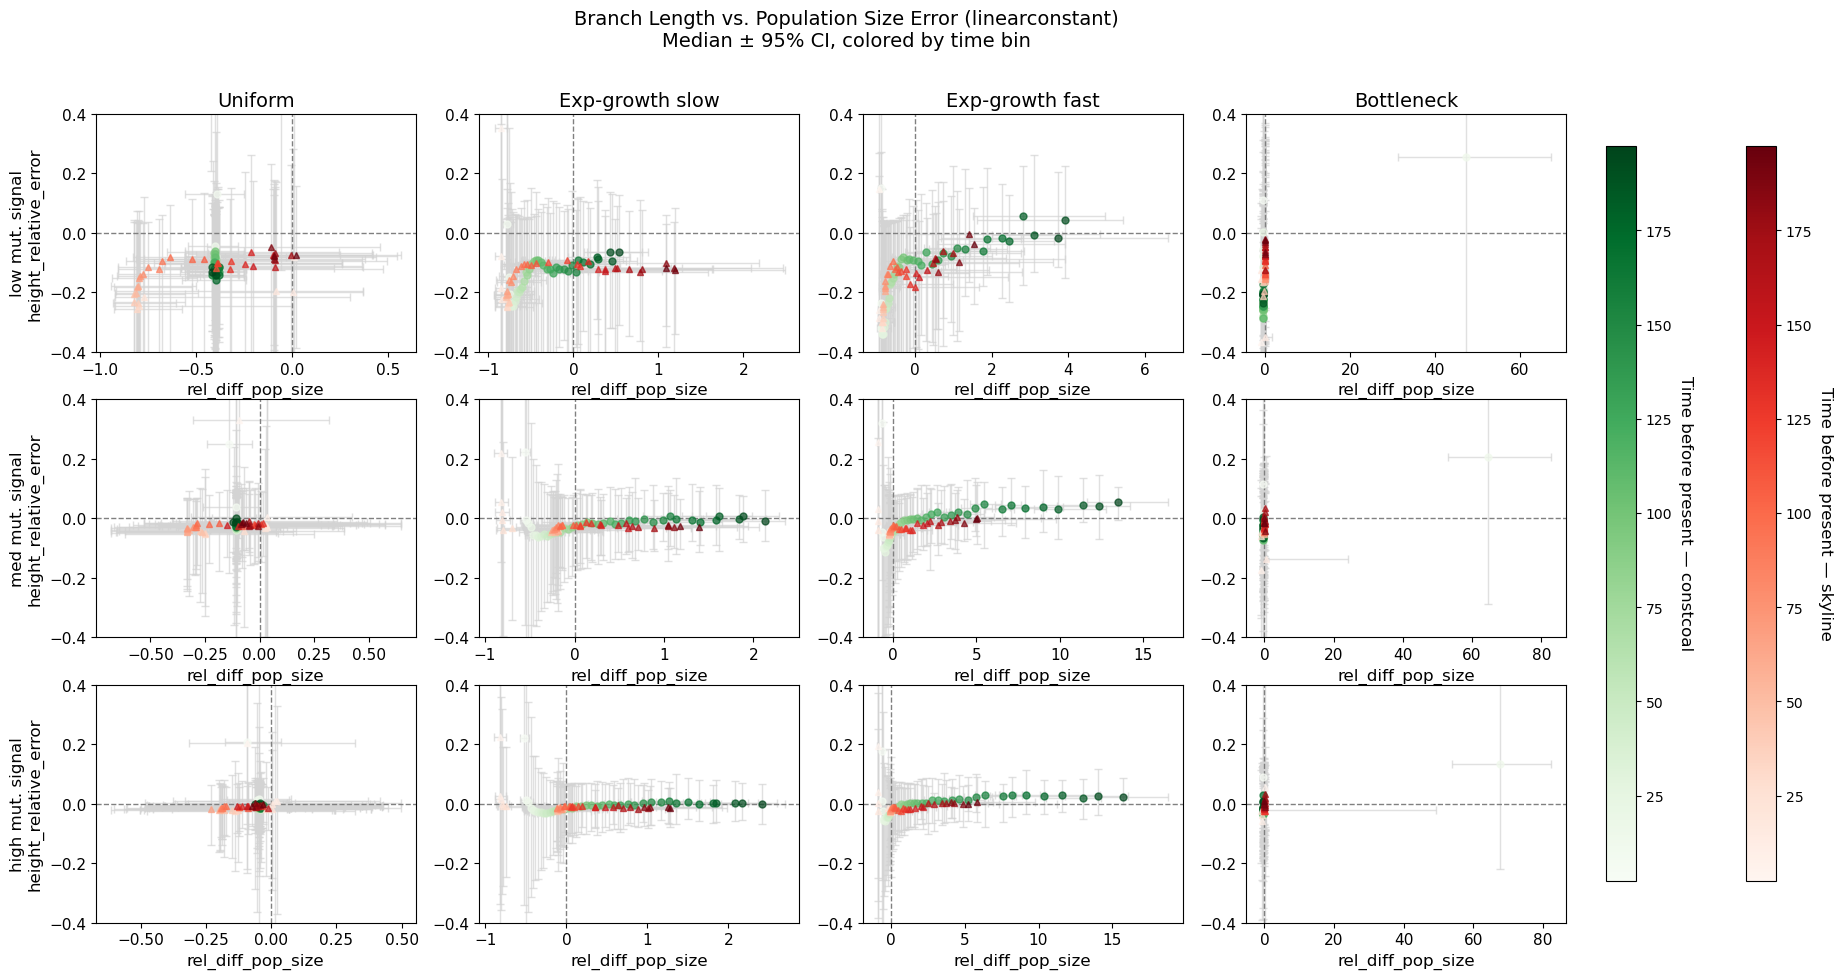

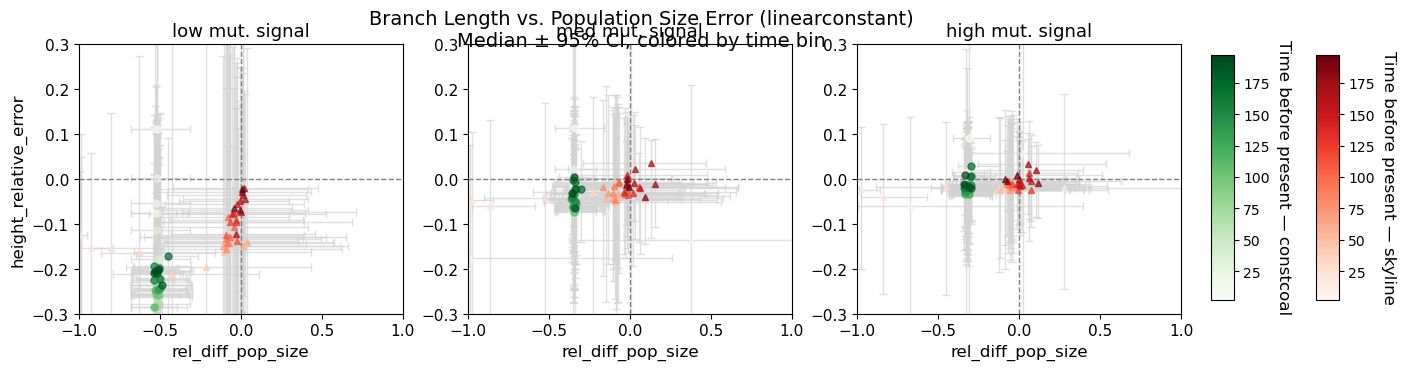

In [ ]:
# only keep bins with at least 10 values, restricted to the last 200 years, bin_width = 5

plot_bl_vs_popsize_error_timecoloring_dualmodel(tree_metrics_combined_internal, sampling = "independenthomochronous", bin_width=5, time_col="height_sim",
                                                    pop_error_col="rel_diff_pop_size", bl_error_col="height_relative_error", min_values_per_bin = 10,
                                                    x_range=None, y_range=(-0.4,0.4), show_errorbars=True, time_limit = 200, log_colorbar = False,
                                                    pop_models = ['uniform', 'expgrowthslow', 'expgrowthfast'])

plot_bl_vs_popsize_error_timecoloring_dualmodel(tree_metrics_combined_internal, sampling = "independenthomochronous", bin_width=5, time_col="height_sim",
                                                    pop_error_col="rel_diff_pop_size", bl_error_col="height_abs_relative_error", min_values_per_bin = 10,
                                                    x_range=None, y_range=(0,0.4), show_errorbars=True, time_limit = 200, log_colorbar = False,
                                                    pop_models = ['uniform', 'expgrowthslow', 'expgrowthfast'])

plot_bl_vs_popsize_error_timecoloring_dualmodel(tree_metrics_combined_internal, sampling = "independenthomochronous", bin_width=5, time_col="height_sim",
                                                    pop_error_col="cum_pop_size_error_relsim", bl_error_col="height_relative_error", min_values_per_bin = 10,
                                                    x_range=(-2,2), y_range=(-0.4,0.4), show_errorbars=True, time_limit = 200, log_colorbar = False,
                                                    pop_models = ['uniform', 'expgrowthslow', 'expgrowthfast'])

plot_bl_vs_popsize_error_timecoloring_dualmodel(tree_metrics_combined_internal, sampling = "linearconstant", bin_width=5, time_col="height_sim",
                                                    pop_error_col="rel_diff_pop_size", bl_error_col="height_relative_error", min_values_per_bin = 10,
                                                    x_range=None, y_range=(-0.4,0.4), show_errorbars=True, time_limit = 200, log_colorbar = False)

plot_bl_vs_popsize_error_timecoloring_dualmodel(tree_metrics_combined_internal, sampling = "linearconstant", bin_width=5, time_col="height_sim",
                                                    pop_error_col="rel_diff_pop_size", bl_error_col="height_relative_error", min_values_per_bin = 10,
                                                    x_range=(-1,1), y_range=(-0.3,0.3), show_errorbars=True, time_limit = 200, log_colorbar = False, 
                                                    pop_models = ['bottleneck'])

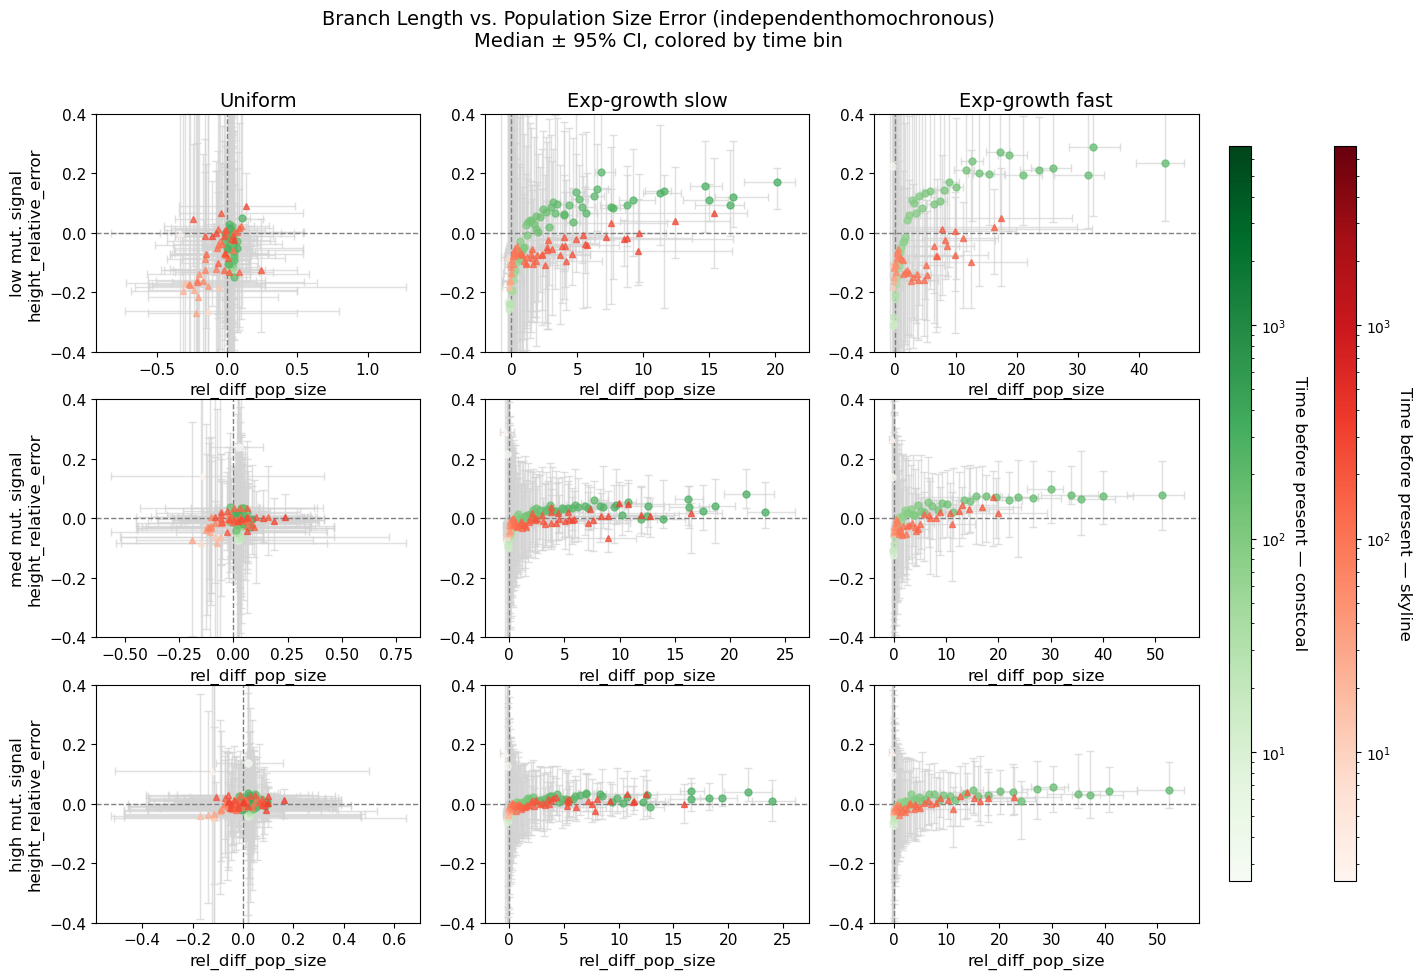

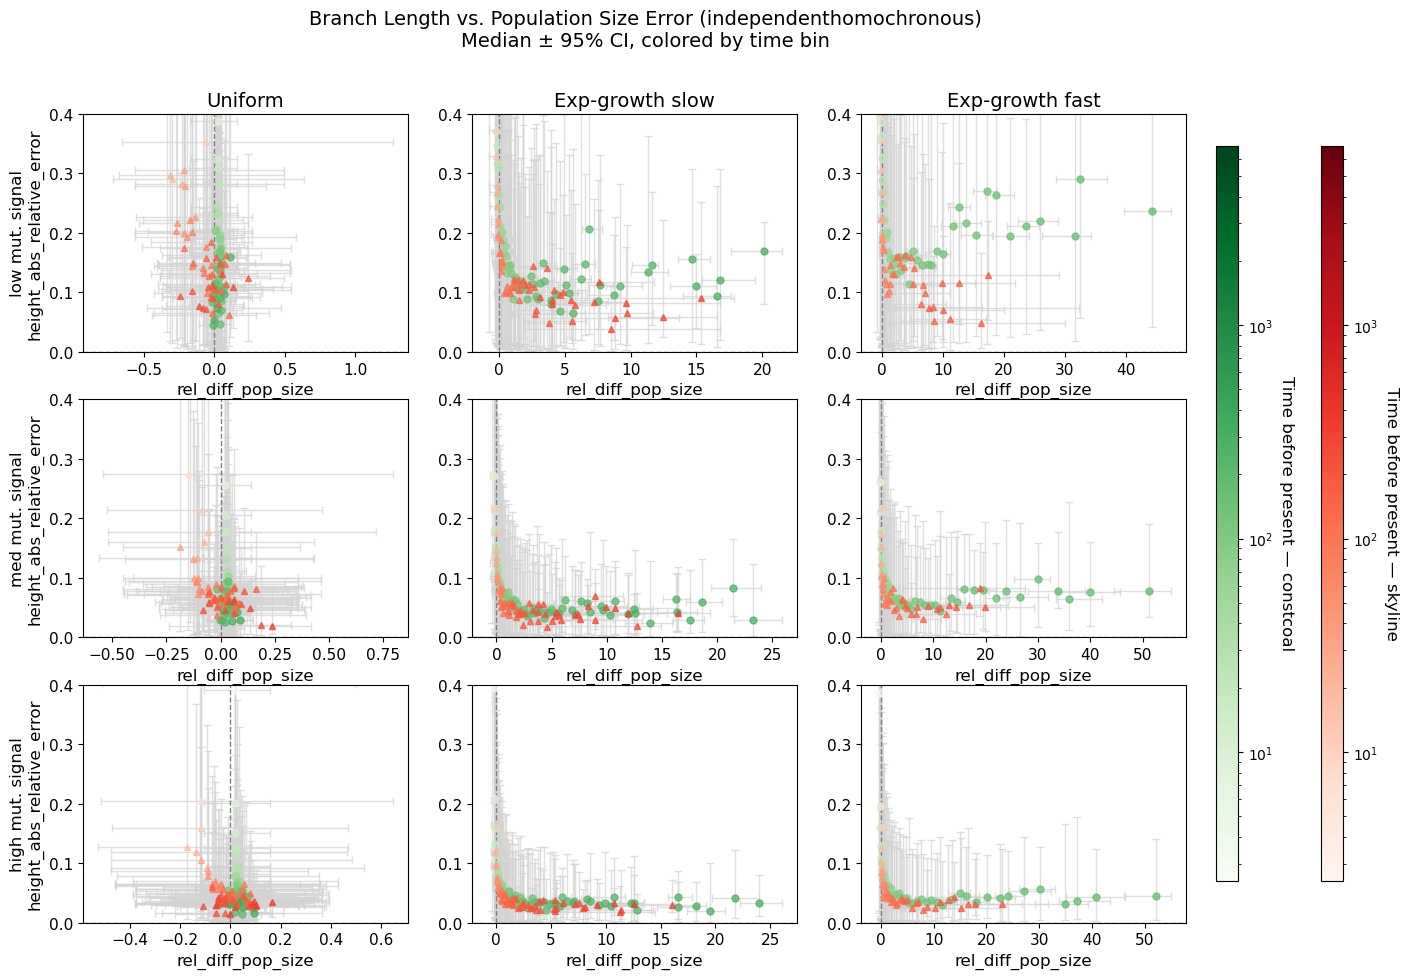

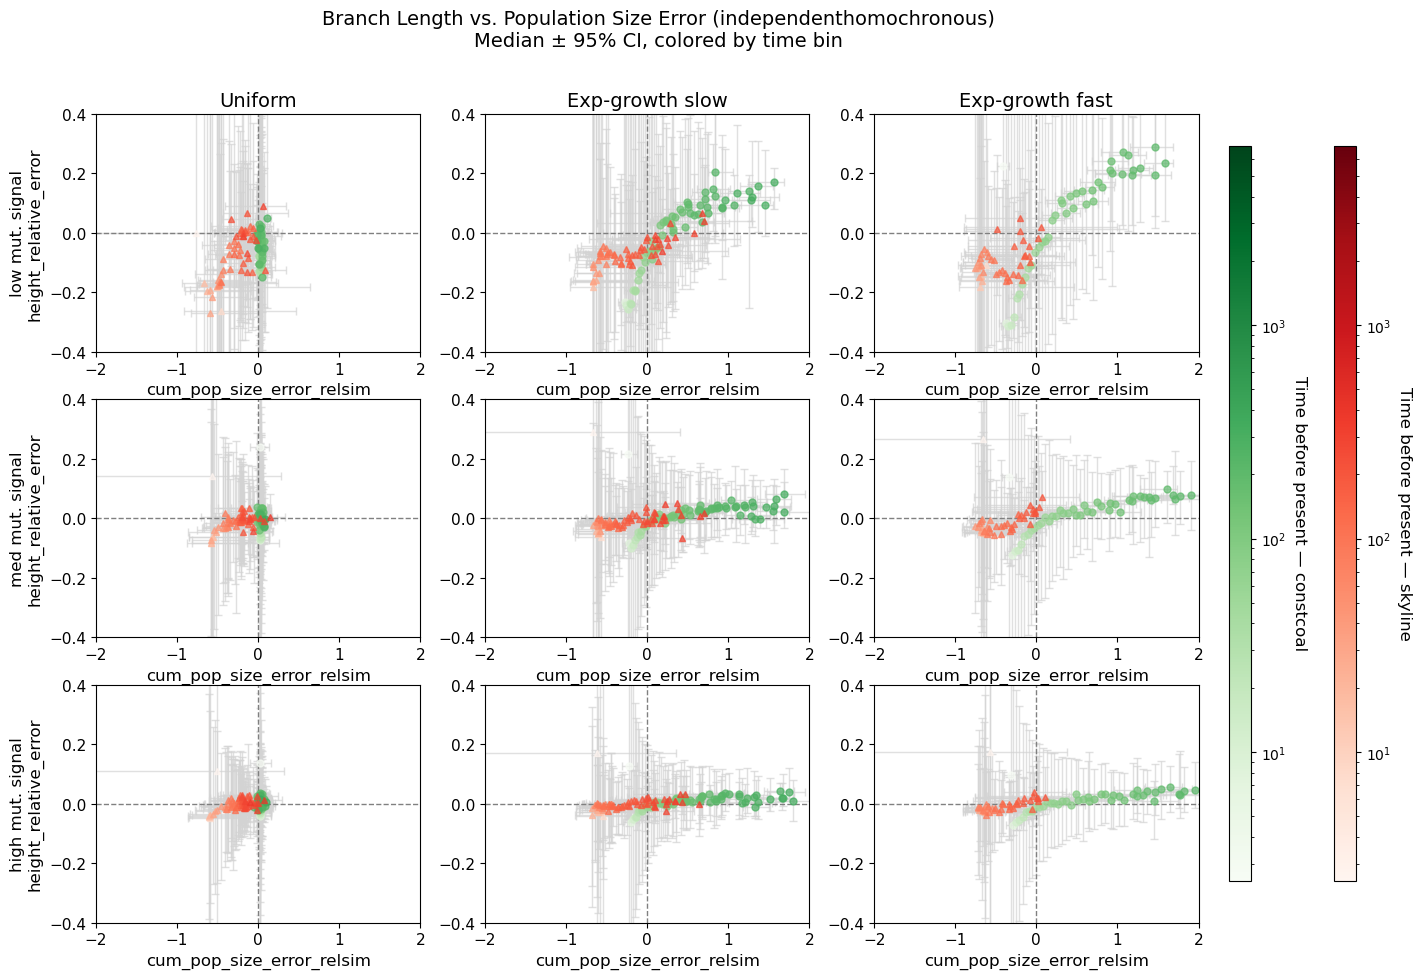

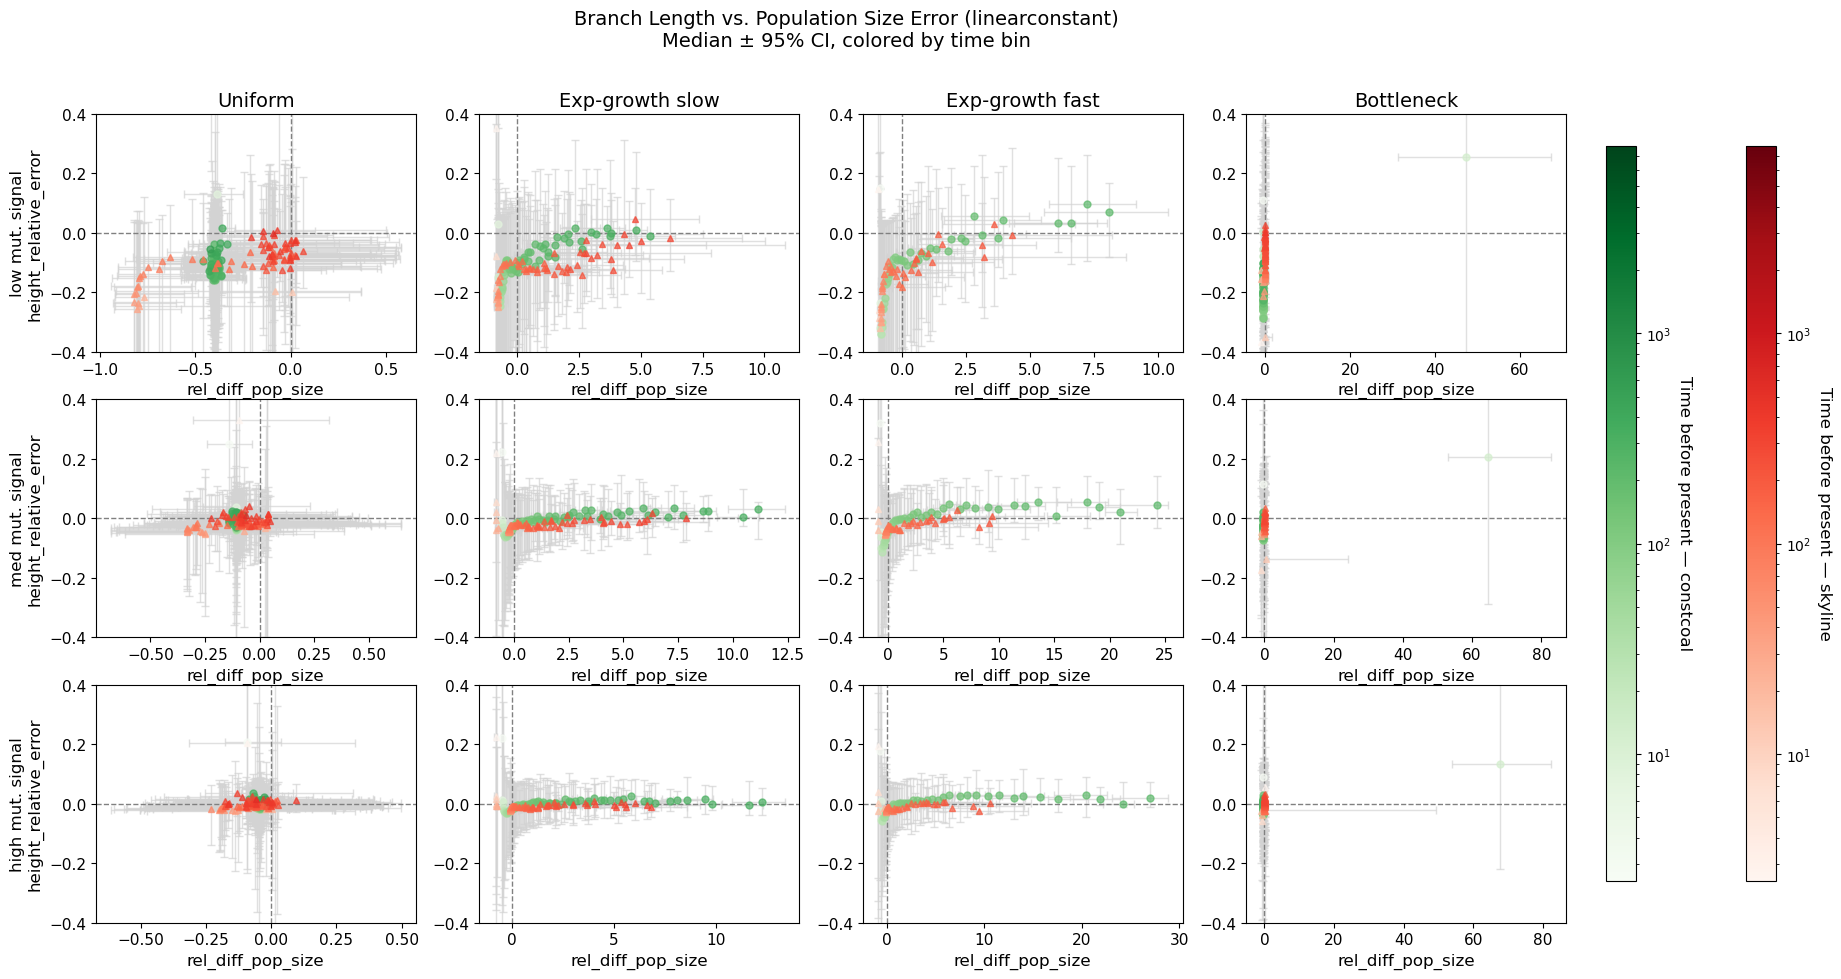

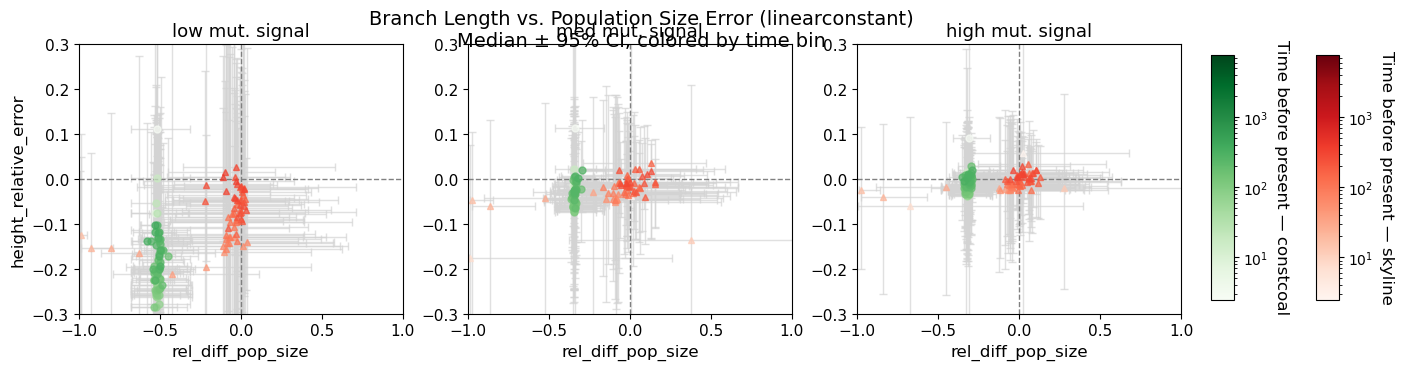

In [19]:
# only keep bins with at least 10 values, restricted to the last 200 years, bin_width = 5

plot_bl_vs_popsize_error_timecoloring_dualmodel(tree_metrics_combined_internal, sampling = "independenthomochronous", bin_width=5, time_col="height_sim",
                                                    pop_error_col="rel_diff_pop_size", bl_error_col="height_relative_error", min_values_per_bin = 10,
                                                    x_range=None, y_range=(-0.4,0.4), show_errorbars=True, time_limit = None, log_colorbar = True,
                                                    pop_models = ['uniform', 'expgrowthslow', 'expgrowthfast'])

plot_bl_vs_popsize_error_timecoloring_dualmodel(tree_metrics_combined_internal, sampling = "independenthomochronous", bin_width=5, time_col="height_sim",
                                                    pop_error_col="rel_diff_pop_size", bl_error_col="height_abs_relative_error", min_values_per_bin = 10,
                                                    x_range=None, y_range=(0,0.4), show_errorbars=True, time_limit = None, log_colorbar = True,
                                                    pop_models = ['uniform', 'expgrowthslow', 'expgrowthfast'])

plot_bl_vs_popsize_error_timecoloring_dualmodel(tree_metrics_combined_internal, sampling = "independenthomochronous", bin_width=5, time_col="height_sim",
                                                    pop_error_col="cum_pop_size_error_relsim", bl_error_col="height_relative_error", min_values_per_bin = 10,
                                                    x_range=(-2,2), y_range=(-0.4,0.4), show_errorbars=True, time_limit = None, log_colorbar = True,
                                                    pop_models = ['uniform', 'expgrowthslow', 'expgrowthfast'])

plot_bl_vs_popsize_error_timecoloring_dualmodel(tree_metrics_combined_internal, sampling = "linearconstant", bin_width=5, time_col="height_sim",
                                                    pop_error_col="rel_diff_pop_size", bl_error_col="height_relative_error", min_values_per_bin = 10,
                                                    x_range=None, y_range=(-0.4,0.4), show_errorbars=True, time_limit = None, log_colorbar = True)

plot_bl_vs_popsize_error_timecoloring_dualmodel(tree_metrics_combined_internal, sampling = "linearconstant", bin_width=5, time_col="height_sim",
                                                    pop_error_col="rel_diff_pop_size", bl_error_col="height_relative_error", min_values_per_bin = 10,
                                                    x_range=(-1,1), y_range=(-0.3,0.3), show_errorbars=True, time_limit = None, log_colorbar = True, 
                                                    pop_models = ['bottleneck'])

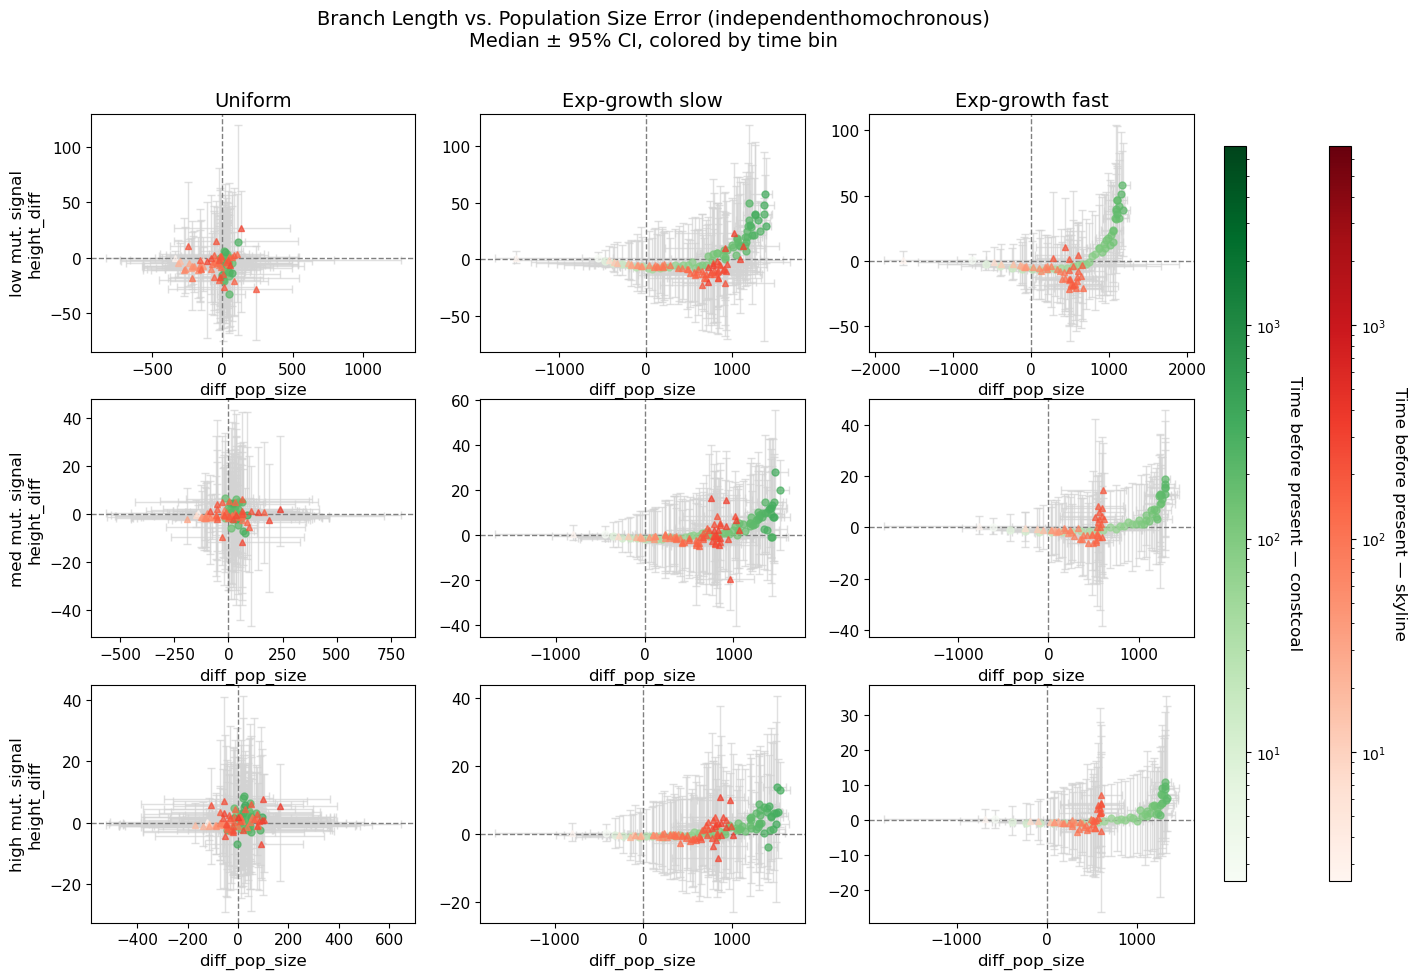

In [ ]:
# only keep bins with at least 10 values, bin_width = 5

plot_bl_vs_popsize_error_timecoloring_dualmodel(tree_metrics_combined_internal, sampling = "independenthomochronous", bin_width=5, time_col="height_sim",
                                                    pop_error_col="diff_pop_size", bl_error_col="height_diff", min_values_per_bin = 10,
                                                    x_range=None, y_range=None, show_errorbars=True, time_limit = None, log_colorbar = True,
                                                    pop_models = ['uniform', 'expgrowthslow', 'expgrowthfast'])

plot_bl_vs_popsize_error_timecoloring_dualmodel(tree_metrics_combined_internal, sampling = "independenthomochronous", bin_width=5, time_col="height_sim",
                                                    pop_error_col="cum_pop_size_error", bl_error_col="height_diff", min_values_per_bin = 10,
                                                    x_range=(-200000,400000), y_range=None, show_errorbars=True, time_limit = None, log_colorbar = True,
                                                    pop_models = ['uniform', 'expgrowthslow', 'expgrowthfast'])

plot_bl_vs_popsize_error_timecoloring_dualmodel(tree_metrics_combined_internal, sampling = "linearconstant", bin_width=5, time_col="height_sim",
                                                    pop_error_col="diff_pop_size", bl_error_col="height_diff", min_values_per_bin = 10,
                                                    x_range=None, y_range=None, show_errorbars=True, time_limit = None, log_colorbar = True)
                                                    
plot_bl_vs_popsize_error_timecoloring_dualmodel(tree_metrics_combined_internal, sampling = "linearconstant", bin_width=5, time_col="height_sim",
                                                    pop_error_col="cum_pop_size_error", bl_error_col="height_diff", min_values_per_bin = 10,
                                                    x_range=(-300000, 200000), y_range=None, show_errorbars=True, time_limit = None, log_colorbar = True)